# Prophet Decomposition: April 2026 vs June 2026 Desktop World DAU

Compares the **rolled-up Mozaic-level Prophet model** for desktop legacy DAU between the
April 2026 cycle (forecast_start=2026-04-01) and the latest June 2026 cycle (forecast_start=2026-05-17).

The Mozaic class fits a single Prophet model on the world-rolled-up holiday-detrended DAU.
That model exposes:
- A **trend** (logistic growth, or linear depending on data shape).
- A **yearly** seasonality (Fourier basis).
- Two conditional weekly seasonalities: **weekly_historical** (training data before the recent window)
  and **weekly_recent** (the recent window + forecast horizon).

This notebook re-fits each Mozaic's Prophet model via its saved `forecast_model` factory function,
then overlays the trend, yearly, and weekly_recent components from April and June on three sets of axes.

The Mozaic dict stores `.trend` (a Series) directly, so we cross-check the re-fit by confirming
the re-fitted trend matches the stored trend.


In [1]:
# [setup]
import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.0f}".format)

REPO_ROOT = Path("/Users/brendanwells/work/mozaic-daily")

# Make mozaic_daily importable (not strictly needed here but consistent with other notebooks).
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

APRIL_DIR = REPO_ROOT / "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6"
JUNE_DIR  = REPO_ROOT / "data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6"

APRIL_PKL = APRIL_DIR / "mozaic_objects.legacy_desktop.2026-04-01.pkl"
JUNE_PKL  = JUNE_DIR  / "mozaic_objects.legacy_desktop.2026-05-17.pkl"

print(f"April pkl exists: {APRIL_PKL.exists()}")
print(f"June  pkl exists: {JUNE_PKL.exists()}")
if not JUNE_PKL.exists():
    raise FileNotFoundError(
        f"June pkl missing at {JUNE_PKL}. Run scripts/run_main.py with "
        f"--data-sources legacy_desktop --metrics DAU --forecast-start-date 2026-05-17 "
        f"--output-dir {JUNE_DIR} to produce it."
    )

APRIL_PARAMS = json.loads((APRIL_DIR / "parameters.json").read_text())
JUNE_PARAMS  = json.loads((JUNE_DIR / "parameters.json").read_text())
print("\nApril parameters:")
print(json.dumps(APRIL_PARAMS, indent=2))
print("\nJune parameters:")
print(json.dumps(JUNE_PARAMS, indent=2))


April pkl exists: True
June  pkl exists: True

April parameters:
{
  "forecast_start_date": "2026-04-01",
  "desktop": {
    "prophet_changepoint_prior_scale": 0.15983,
    "prophet_changepoint_range": 0.7,
    "prophet_seasonality_prior_scale": 0.00825,
    "prophet_recent_weeks": 13,
    "holiday_threshold": -0.05,
    "holiday_max_radius": 5,
    "holiday_min_radius": 3,
    "holiday_effect_floor": -0.6
  }
}

June parameters:
{
  "platform": "legacy_desktop",
  "forecast_start_date": "2026-05-17",
  "prophet_recent_weeks": 13,
  "changepoint_prior_scale": 0.15983,
  "holiday_threshold": -0.05,
  "holiday_max_radius": 5,
  "holiday_min_radius": 3,
  "holiday_effect_floor": -0.6
}


In [2]:
# [load-mozaics]
# Each pkl is {metric: Mozaic}. We pull the DAU Mozaic from each.

with open(APRIL_PKL, "rb") as f:
    april_obj = pickle.load(f)
with open(JUNE_PKL, "rb") as f:
    june_obj = pickle.load(f)

apr_mz = april_obj["DAU"]
jun_mz = june_obj["DAU"]

print(f"April Mozaic: {len(apr_mz.tiles)} tiles, "
      f"historical {apr_mz.historical_dates.min().date()} \u2192 {apr_mz.historical_dates.max().date()}, "
      f"forecast {apr_mz.forecast_dates.min().date()} \u2192 {apr_mz.forecast_dates.max().date()}")
print(f"June  Mozaic: {len(jun_mz.tiles)} tiles, "
      f"historical {jun_mz.historical_dates.min().date()} \u2192 {jun_mz.historical_dates.max().date()}, "
      f"forecast {jun_mz.forecast_dates.min().date()} \u2192 {jun_mz.forecast_dates.max().date()}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


April Mozaic: 45 tiles, historical 2020-01-01 → 2026-04-06, forecast 2026-04-01 → 2027-12-31
June  Mozaic: 45 tiles, historical 2020-01-01 → 2026-05-16, forecast 2026-05-17 → 2027-12-31


## Re-fit Prophet via the saved factory

The Mozaic pickle stores `forecast_model` as a *callable* (the model factory), not as a
fitted Prophet object. To inspect trend / yearly / weekly components, we have to re-run the
factory on each Mozaic's saved `holiday_detrended_historical_data` to produce a fitted Prophet
model.

This is deterministic (Prophet seeds with `np.random.seed(42)` inside the factory) so the
re-fit reproduces the original fit.


In [3]:
# [refit-prophet]
# Call each Mozaic's saved factory with that Mozaic's exact inputs and config.
# The factory returns (predictive_samples, fitted_prophet_model, prophet_forecast).
# We keep the fitted Prophet model `m` for decomposition.

def refit_world_prophet(mz, params: dict):
    """Re-fit the Mozaic-level Prophet model via the saved factory."""
    cps = params.get("changepoint_prior_scale") or params.get("prophet_changepoint_prior_scale")
    recent_weeks = params.get("prophet_recent_weeks", 13)
    # The April parameters.json uses different key naming than June's; tolerate both.
    if cps is None:
        cps = APRIL_PARAMS.get("desktop", {}).get("prophet_changepoint_prior_scale", 0.15983)
    _samples, m, _fc = mz.forecast_model(
        mz.holiday_detrended_historical_data,
        mz.historical_dates,
        mz.forecast_dates,
        recent_weeks=recent_weeks,
        changepoint_prior_scale=cps,
    )
    return m


print("Re-fitting April Prophet model...")
apr_m = refit_world_prophet(apr_mz, APRIL_PARAMS.get("desktop", APRIL_PARAMS))
print("Re-fitting June Prophet model...")
jun_m = refit_world_prophet(jun_mz, JUNE_PARAMS)
print(f"\nApril Prophet growth: {apr_m.growth}, seasonalities: {list(apr_m.seasonalities)}")
print(f"June  Prophet growth: {jun_m.growth}, seasonalities: {list(jun_m.seasonalities)}")


Re-fitting April Prophet model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: divide by zero encountered in matmul
  Xb_m = np.matmul(seasonal_features.values, beta * s_m.values)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: overflow encountered in matmul
  Xb_m = np.matmul(seasonal_features.values,

Re-fitting June Prophet model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: divide by zero encountered in matmul
  Xb_m = np.matmul(seasonal_features.values, beta * s_m.values)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: overflow encountered in matmul
  Xb_m = np.matmul(seasonal_features.values,


April Prophet growth: logistic, seasonalities: ['weekly_historical', 'weekly_recent', 'yearly']
June  Prophet growth: logistic, seasonalities: ['weekly_historical', 'weekly_recent', 'yearly']


In [4]:
# [build-prediction-frames]
# Build a unified prediction frame for each model spanning training-start \u2192 forecast-end.
# This gives Prophet a chance to render all components across the full timeline.

def build_full_future(mz, m):
    """Build a future DataFrame for `m.predict` covering full historical + forecast horizon."""
    full_dates = pd.DatetimeIndex(
        list(mz.historical_dates) + list(mz.forecast_dates)
    ).unique().sort_values()
    df = pd.DataFrame({"ds": full_dates})
    forecast_start = mz.forecast_dates[0]
    recent_cutoff = forecast_start - pd.Timedelta(weeks=13)
    df["is_historical"] = df["ds"] < recent_cutoff
    df["is_recent"] = df["ds"] >= recent_cutoff
    if m.growth == "logistic":
        # The Mozaic's saved holiday_detrended_historical_data is in raw DAU units.
        observed = mz.holiday_detrended_historical_data.dropna()
        cap = observed.tail(366).max() * 1.05
        floor = observed.tail(366).min() * (1.0 if cap > 100e6 else 0.92)
        df["cap"] = cap
        df["floor"] = floor
    return df


apr_future = build_full_future(apr_mz, apr_m)
jun_future = build_full_future(jun_mz, jun_m)
print(f"April future rows: {len(apr_future)}, ds {apr_future['ds'].min().date()} \u2192 {apr_future['ds'].max().date()}")
print(f"June  future rows: {len(jun_future)}, ds {jun_future['ds'].min().date()} \u2192 {jun_future['ds'].max().date()}")

print("\nPredicting decomposition for each model...")
apr_pred = apr_m.predict(apr_future)
jun_pred = jun_m.predict(jun_future)
print(f"April predict columns: {sorted(apr_pred.columns)}")
print(f"\nJune  predict columns: {sorted(jun_pred.columns)}")


April future rows: 2922, ds 2020-01-01 → 2027-12-31
June  future rows: 2922, ds 2020-01-01 → 2027-12-31

Predicting decomposition for each model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

April predict columns: ['additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'cap', 'ds', 'floor', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'trend', 'trend_lower', 'trend_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'yhat', 'yhat_lower', 'yhat_upper']

June  predict columns: ['additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'cap', 'ds', 'floor', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'trend', 'trend_lower', 'trend_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'yhat', 'yhat_lower', 'yhat_upper']


In [5]:
# [cross-check-trend]
# Sanity check: Prophet's re-fitted trend should be very close to the .trend Series
# the Mozaic saved. Differences would mean we are not reproducing the original fit.

def reindex_pred_to_dates(pred, mz):
    """Reindex predict() output by date, then slice to the historical+forecast index used by .trend."""
    out = pred.set_index("ds")
    # mz.trend is indexed 0..n-1; reconstruct its date index from historical+forecast
    return out


apr_pred_by_date = apr_pred.set_index("ds")
jun_pred_by_date = jun_pred.set_index("ds")

# Build a date index for the saved .trend (mz.trend is indexed 0..n-1, len 640 for April).
# It corresponds to forecast_dates per the factory (which predicts on `future = forecast_dates`).
apr_trend_dates = pd.DatetimeIndex(apr_mz.forecast_dates)
jun_trend_dates = pd.DatetimeIndex(jun_mz.forecast_dates)
apr_saved_trend = pd.Series(apr_mz.trend.values, index=apr_trend_dates)
jun_saved_trend = pd.Series(jun_mz.trend.values, index=jun_trend_dates)

# Refit trend on same dates
apr_refit_trend_at_forecast = apr_pred_by_date.loc[apr_trend_dates, "trend"]
jun_refit_trend_at_forecast = jun_pred_by_date.loc[jun_trend_dates, "trend"]

apr_diff = (apr_saved_trend.values - apr_refit_trend_at_forecast.values)
jun_diff = (jun_saved_trend.values - jun_refit_trend_at_forecast.values)
print(f"April saved-trend vs refit-trend at forecast dates: max |diff| = {np.abs(apr_diff).max():,.2f}, mean = {np.abs(apr_diff).mean():,.2f}")
print(f"June  saved-trend vs refit-trend at forecast dates: max |diff| = {np.abs(jun_diff).max():,.2f}, mean = {np.abs(jun_diff).mean():,.2f}")
print()
print("If both maxes are < ~1k DAU we've faithfully re-fit. Larger gaps would suggest the")
print("factory state we used differs from what produced the saved .trend.")


April saved-trend vs refit-trend at forecast dates: max |diff| = 0.00, mean = 0.00
June  saved-trend vs refit-trend at forecast dates: max |diff| = 0.00, mean = 0.00

If both maxes are < ~1k DAU we've faithfully re-fit. Larger gaps would suggest the
factory state we used differs from what produced the saved .trend.


## Plot 1 — Trend

The trend component of each Prophet fit, plotted across the full timeline. The forecast-start
date is marked for each run. Differences in slope or level at any point reflect a structural
difference in what Prophet thinks the underlying level is doing.


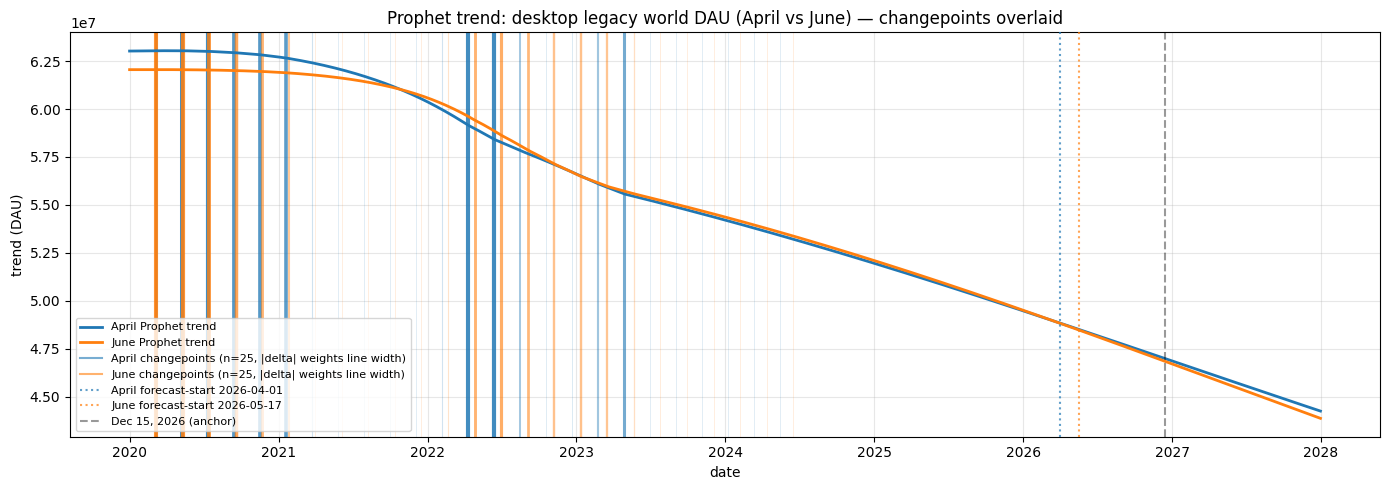


April trend @ 2026-12-15:     46,982,768
June  trend @ 2026-12-15:     46,836,840
Trend gap (June − April): -145,928

April top 5 changepoints by |delta|:
      date  delta
2022-06-13      2
2020-07-11     -2
2022-04-10      2
2020-05-08     -2
2020-09-12     -2

June  top 5 changepoints by |delta|:
      date  delta
2020-05-10     -3
2020-03-06     -3
2020-07-14     -3
2020-09-17     -2
2022-07-01      2


In [6]:
# [plot-trend]
# Prophet trends overlaid, with each model's changepoints marked.
#
# Each Prophet fit has n_changepoints=25 distributed across the first
# changepoint_range=0.7 of the training history. Many of those have very small
# |delta| (no actual trend change). We mark each changepoint as a vertical line
# whose alpha and line-width scale with |delta| relative to that model's max,
# so visually-prominent ticks are the ones that actually moved the trend.

import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

apr_trend_full = apr_pred_by_date["trend"]
jun_trend_full = jun_pred_by_date["trend"]

ax.plot(apr_trend_full.index, apr_trend_full.values, color="tab:blue", lw=2, label="April Prophet trend", zorder=3)
ax.plot(jun_trend_full.index, jun_trend_full.values, color="tab:orange", lw=2, label="June Prophet trend", zorder=3)


def plot_changepoints(ax, prophet_m, color, label):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)  # average across MCMC chains (here just MAP, 1 row)
    abs_deltas = np.abs(deltas)
    max_abs = abs_deltas.max() if abs_deltas.max() > 0 else 1.0
    for ds, d in zip(cps, deltas):
        weight = abs(d) / max_abs                              # 0..1
        alpha = 0.15 + 0.7 * weight                             # 0.15..0.85
        lw = 0.6 + 2.4 * weight                                 # 0.6..3.0
        ax.axvline(ds, color=color, ls="-", alpha=alpha, lw=lw, zorder=2)
    # one dummy line for the legend entry
    ax.axvline(cps.iloc[0], color=color, ls="-", alpha=0.6, lw=1.5,
               label=f"{label} changepoints (n={len(cps)}, |delta| weights line width)")


plot_changepoints(ax, apr_m, "tab:blue", "April")
plot_changepoints(ax, jun_m, "tab:orange", "June")

ax.axvline(apr_mz.forecast_dates[0], color="tab:blue", ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(jun_mz.forecast_dates[0], color="tab:orange", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026 (anchor)", zorder=4)

ax.set_title("Prophet trend: desktop legacy world DAU (April vs June) — changepoints overlaid")
ax.set_ylabel("trend (DAU)")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Trend value at Dec 15 each side
anchor = pd.Timestamp("2026-12-15")
print(f"\nApril trend @ {anchor.date()}: {apr_trend_full.loc[anchor]:>14,.0f}")
print(f"June  trend @ {anchor.date()}: {jun_trend_full.loc[anchor]:>14,.0f}")
print(f"Trend gap (June − April): {(jun_trend_full.loc[anchor] - apr_trend_full.loc[anchor]):+,.0f}")

# Top 5 changepoints by absolute delta for each model — these are the ones that mattered.
def top_changepoints(prophet_m, n=5):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    rows = pd.DataFrame({"date": cps.values, "delta": deltas})
    rows["abs_delta"] = rows["delta"].abs()
    return rows.sort_values("abs_delta", ascending=False).head(n)[["date","delta"]]


print(f"\nApril top 5 changepoints by |delta|:")
print(top_changepoints(apr_m).to_string(index=False))
print(f"\nJune  top 5 changepoints by |delta|:")
print(top_changepoints(jun_m).to_string(index=False))


## Plot 2 — Yearly seasonality

Yearly seasonality is a multiplicative (fractional) modifier on top of trend when
`seasonality_mode='multiplicative'` (which the factory selects when magnitude correlates with
volatility — almost always true for these series). Plotted across one calendar year so the shape
is comparable.


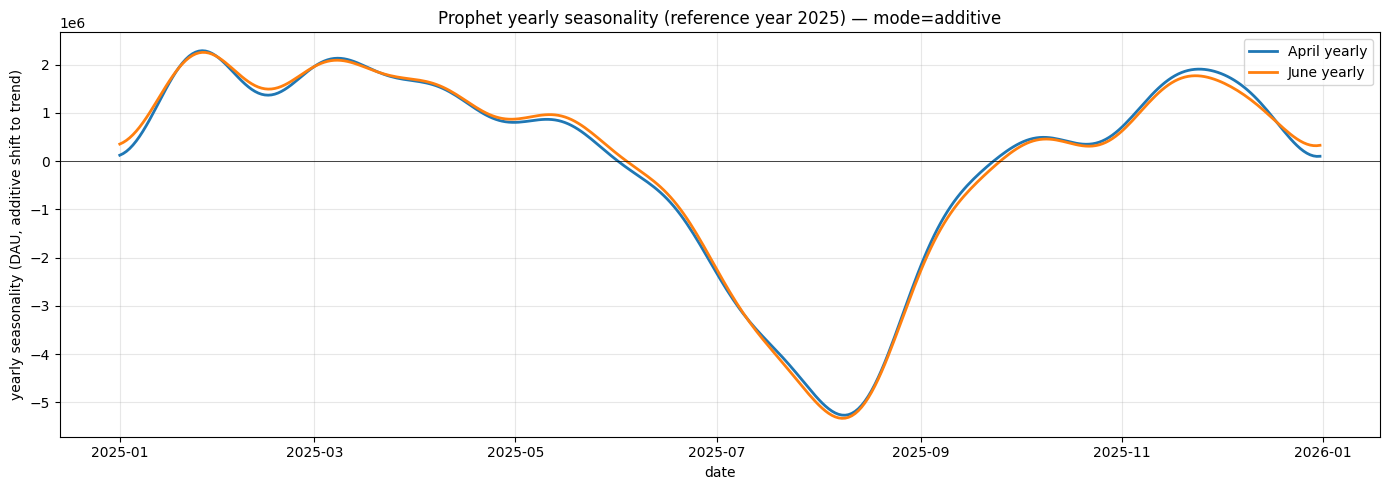


April yearly range over 2025: -5,263,708 DAU  →  +2,287,291 DAU
June  yearly range over 2025: -5,328,760 DAU  →  +2,253,276 DAU

For scale: April mean 2025 trend = 50,728,535 DAU; June = 50,823,297
  April yearly range as % of trend: -10.38% → +4.51%
  June  yearly range as % of trend: -10.48% → +4.43%


In [7]:
# [plot-yearly]
# Plot yearly seasonality over a single representative year for easy shape comparison.
# Use 2025 as the reference year (it falls inside both fits' training history).
#
# Both Mozaic-fit Prophet models use seasonality_mode='additive' (the factory chose
# additive because magnitude/volatility correlation didn't trigger multiplicative).
# So `yearly` is a raw DAU additive offset to trend, not a fractional modifier.

ref_year_start = pd.Timestamp("2025-01-01")
ref_year_end   = pd.Timestamp("2025-12-31")

apr_yearly = apr_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]
jun_yearly = jun_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]

mode_apr = apr_m.seasonality_mode
mode_jun = jun_m.seasonality_mode
assert mode_apr == mode_jun, f"Mode mismatch: April={mode_apr}, June={mode_jun}"

fig, ax = plt.subplots(figsize=(14, 5))
if mode_apr == "additive":
    ax.plot(apr_yearly.index, apr_yearly.values, color="tab:blue", lw=2, label="April yearly")
    ax.plot(jun_yearly.index, jun_yearly.values, color="tab:orange", lw=2, label="June yearly")
    ax.set_ylabel("yearly seasonality (DAU, additive shift to trend)")
    fmt = "{:>+,.0f} DAU"
else:
    ax.plot(apr_yearly.index, apr_yearly.values * 100, color="tab:blue", lw=2, label="April yearly")
    ax.plot(jun_yearly.index, jun_yearly.values * 100, color="tab:orange", lw=2, label="June yearly")
    ax.set_ylabel("yearly seasonality (% of trend, multiplicative)")
    fmt = "{:>+.2f}%"
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Prophet yearly seasonality (reference year 2025) — mode={mode_apr}")
ax.set_xlabel("date")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if mode_apr == "additive":
    print(f"\nApril yearly range over 2025: {apr_yearly.min():>+,.0f} DAU  →  {apr_yearly.max():>+,.0f} DAU")
    print(f"June  yearly range over 2025: {jun_yearly.min():>+,.0f} DAU  →  {jun_yearly.max():>+,.0f} DAU")
    # As percent of mean trend over the same window
    apr_trend_mean = apr_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
    jun_trend_mean = jun_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
    print(f"\nFor scale: April mean 2025 trend = {apr_trend_mean:,.0f} DAU; June = {jun_trend_mean:,.0f}")
    print(f"  April yearly range as % of trend: {apr_yearly.min()/apr_trend_mean*100:+.2f}% → {apr_yearly.max()/apr_trend_mean*100:+.2f}%")
    print(f"  June  yearly range as % of trend: {jun_yearly.min()/jun_trend_mean*100:+.2f}% → {jun_yearly.max()/jun_trend_mean*100:+.2f}%")
else:
    print(f"\nApril yearly range over 2025: {apr_yearly.min()*100:+.2f}%  →  {apr_yearly.max()*100:+.2f}%")
    print(f"June  yearly range over 2025: {jun_yearly.min()*100:+.2f}%  →  {jun_yearly.max()*100:+.2f}%")


## Plot 3 — Weekly seasonality

The factory adds two conditional weekly seasonalities:
- `weekly_historical` — active for training data **before** the recent window
- `weekly_recent` — active for the recent window and the forecast horizon

Only `weekly_recent` drives the forecast, so it's the one to compare. Plotted over 14 days so
both weeks are visible.


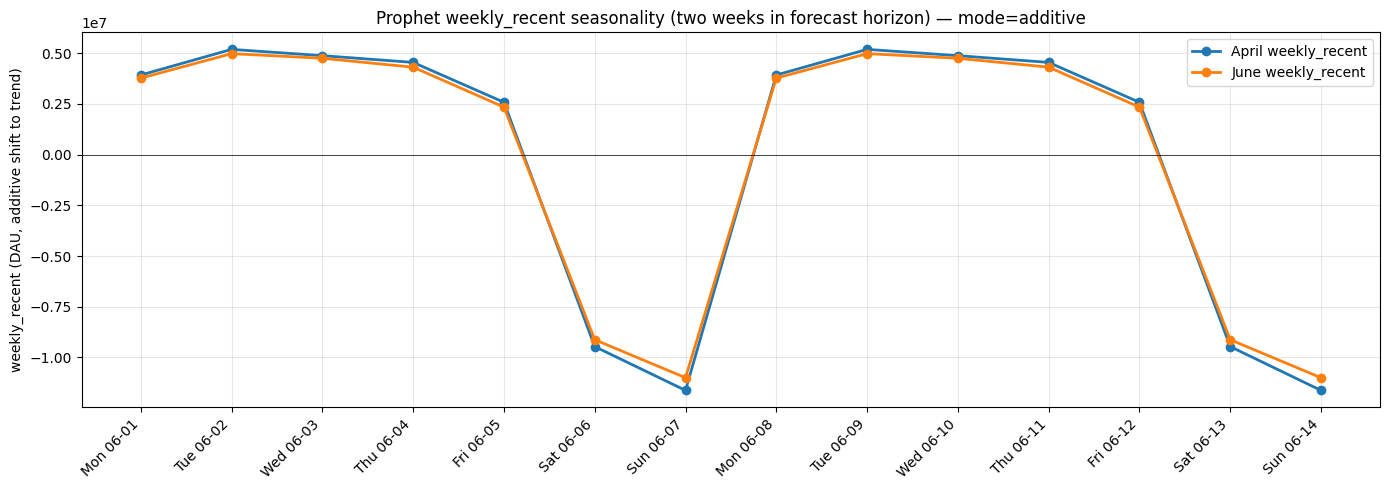


April weekly_recent amplitude (max−min over 7d): +16,800,990 DAU
June  weekly_recent amplitude (max−min over 7d): +15,968,428 DAU

For scale (trend over plot window):
  April: 48,353,565 DAU; weekly amplitude as % of trend: 34.75%
  June:  48,311,679 DAU; weekly amplitude as % of trend: 33.05%


In [8]:
# [plot-weekly]
# weekly_recent is the active seasonality for the forecast horizon. Plot two weeks of it.
# Both models should have a `weekly_recent` column. Additive mode means values are in DAU.

# Anchor: a Monday in the forecast horizon where both models have weekly_recent active.
week_start = pd.Timestamp("2026-06-01")  # Monday in forecast horizon
two_weeks_end = week_start + pd.Timedelta(days=13)

apr_weekly = apr_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]
jun_weekly = jun_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]

mode_apr = apr_m.seasonality_mode
mode_jun = jun_m.seasonality_mode
assert mode_apr == mode_jun, f"Mode mismatch: April={mode_apr}, June={mode_jun}"

fig, ax = plt.subplots(figsize=(14, 5))
day_labels = [(week_start + pd.Timedelta(days=i)).strftime("%a %m-%d") for i in range(len(apr_weekly))]
if mode_apr == "additive":
    ax.plot(range(len(apr_weekly)), apr_weekly.values, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
    ax.plot(range(len(jun_weekly)), jun_weekly.values, color="tab:orange", marker="o", lw=2, label="June weekly_recent")
    ax.set_ylabel("weekly_recent (DAU, additive shift to trend)")
else:
    ax.plot(range(len(apr_weekly)), apr_weekly.values * 100, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
    ax.plot(range(len(jun_weekly)), jun_weekly.values * 100, color="tab:orange", marker="o", lw=2, label="June weekly_recent")
    ax.set_ylabel("weekly_recent (% of trend, multiplicative)")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(len(apr_weekly)))
ax.set_xticklabels(day_labels, rotation=45, ha="right")
ax.set_title(f"Prophet weekly_recent seasonality (two weeks in forecast horizon) — mode={mode_apr}")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Day-of-week amplitude over the first 7 days
apr_amp = apr_weekly.iloc[:7].max() - apr_weekly.iloc[:7].min()
jun_amp = jun_weekly.iloc[:7].max() - jun_weekly.iloc[:7].min()
if mode_apr == "additive":
    print(f"\nApril weekly_recent amplitude (max−min over 7d): {apr_amp:>+,.0f} DAU")
    print(f"June  weekly_recent amplitude (max−min over 7d): {jun_amp:>+,.0f} DAU")
    apr_trend_mean = apr_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
    jun_trend_mean = jun_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
    print(f"\nFor scale (trend over plot window):")
    print(f"  April: {apr_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {apr_amp/apr_trend_mean*100:.2f}%")
    print(f"  June:  {jun_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {jun_amp/jun_trend_mean*100:.2f}%")
else:
    print(f"\nApril weekly_recent amplitude (max−min over 7d): {apr_amp*100:.2f}%")
    print(f"June  weekly_recent amplitude (max−min over 7d): {jun_amp*100:.2f}%")


## Pinning June's changepoints to April's dates

We re-fit a third Prophet model on June's data, but force the changepoint dates to be exactly
the 25 dates Prophet chose for the April fit. Prophet's constructor accepts an explicit
`changepoints=[...]` argument that overrides the auto-generated grid; `n_changepoints` and
`changepoint_range` are ignored when this is set.

Both fits then share the same set of potential changepoint dates. The per-changepoint deltas
(slope adjustments) are still re-fit from June's data — so this isolates the effect of *where*
Prophet allows trend breaks, holding the rest of the model constant.

The 2026-focused trend chart that follows overlays April's trend, the pinned-June trend, both
models' forecasts (yhat), and the observed 2026 training-period DAU.


In [9]:
# [pin-june-to-april-changepoints]
# Fit a third Prophet model: June data + April's changepoint dates.
#
# Prophet's constructor accepts `changepoints=[...]` as an explicit override of the
# auto-generated grid. When set, `n_changepoints` and `changepoint_range` are ignored
# and Prophet places potential changepoints at exactly the given dates. The deltas
# (per-changepoint trend slope adjustments) are re-fit from the June data.
#
# We replicate the factory's logic (logistic growth, cap/floor, conditional weekly
# seasonalities, seed) but swap the changepoint configuration.

import prophet

apr_changepoint_dates = apr_m.changepoints.copy()
print(f"April changepoints to pin onto June fit: {len(apr_changepoint_dates)}")
print(f"  range: {apr_changepoint_dates.min().date()} → {apr_changepoint_dates.max().date()}")
print(f"  all within June training history? {(apr_changepoint_dates <= jun_mz.historical_dates.max()).all()}")

def refit_june_with_pinned_changepoints(mz, changepoint_dates, cps_prior_scale):
    """Reproduce the factory's Prophet setup but use explicit changepoint dates."""
    historical_data = mz.holiday_detrended_historical_data
    historical_dates = mz.historical_dates
    forecast_dates = mz.forecast_dates

    # Logistic-growth branch (matches the factory's path for these series).
    params = dict(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        uncertainty_samples=1000,
        seasonality_prior_scale=0.00825,
        changepoint_prior_scale=cps_prior_scale,
        growth="logistic",
        seasonality_mode="additive",       # additive selected by factory's correlation check
        changepoints=list(changepoint_dates),  # PIN to April's dates
    )

    historical_mask = historical_dates < forecast_dates[0]
    observed = (
        pd.DataFrame({"ds": historical_dates[historical_mask],
                      "y": historical_data[historical_mask]})
        .dropna().reset_index(drop=True).copy(deep=True)
    )
    future = pd.DataFrame({"ds": forecast_dates})

    cap = observed["y"].tail(366).max() * 1.05
    floor = observed["y"].tail(366).min() * (1.0 if cap > 100e6 else 0.92)
    observed["cap"] = cap; observed["floor"] = floor
    future["cap"] = cap;  future["floor"] = floor

    np.random.seed(42)
    m = prophet.Prophet(**params)

    # Conditional weekly seasonalities (replicates _add_conditional_weekly_seasonality).
    recent_cutoff = forecast_dates[0] - pd.Timedelta(weeks=13)
    if observed["ds"].min() >= recent_cutoff:
        observed["is_historical"] = False
        observed["is_recent"] = True
        future["is_historical"] = False
        future["is_recent"] = True
        m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")
    else:
        observed["is_historical"] = observed["ds"] < recent_cutoff
        observed["is_recent"] = observed["ds"] >= recent_cutoff
        future["is_historical"] = False
        future["is_recent"] = True
        m.add_seasonality(name="weekly_historical", period=7, fourier_order=3, condition_name="is_historical")
        m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")

    m.fit(observed)
    return m, future


# June used the same changepoint_prior_scale as April (0.15983), per parameters.json.
jun_cps_prior = JUNE_PARAMS["changepoint_prior_scale"]
print(f"Fitting June with April's changepoint dates (cps_prior_scale={jun_cps_prior}) ...")
jun_pinned_m, jun_pinned_future = refit_june_with_pinned_changepoints(
    jun_mz, apr_changepoint_dates, jun_cps_prior
)

# Predict over the same window as the original fits.
jun_pinned_full_future = build_full_future(jun_mz, jun_pinned_m)
jun_pinned_pred = jun_pinned_m.predict(jun_pinned_full_future)
jun_pinned_pred_by_date = jun_pinned_pred.set_index("ds")
print("Done. Predictions ready.")
print()
print(f"Sanity: pinned-June has {len(jun_pinned_m.changepoints)} changepoints; "
      f"dates match April: {list(jun_pinned_m.changepoints) == list(apr_changepoint_dates)}")


April changepoints to pin onto June fit: 25
  range: 2020-03-05 → 2024-05-15
  all within June training history? True
Fitting June with April's changepoint dates (cps_prior_scale=0.15983) ...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

Done. Predictions ready.

Sanity: pinned-June has 25 changepoints; dates match April: True


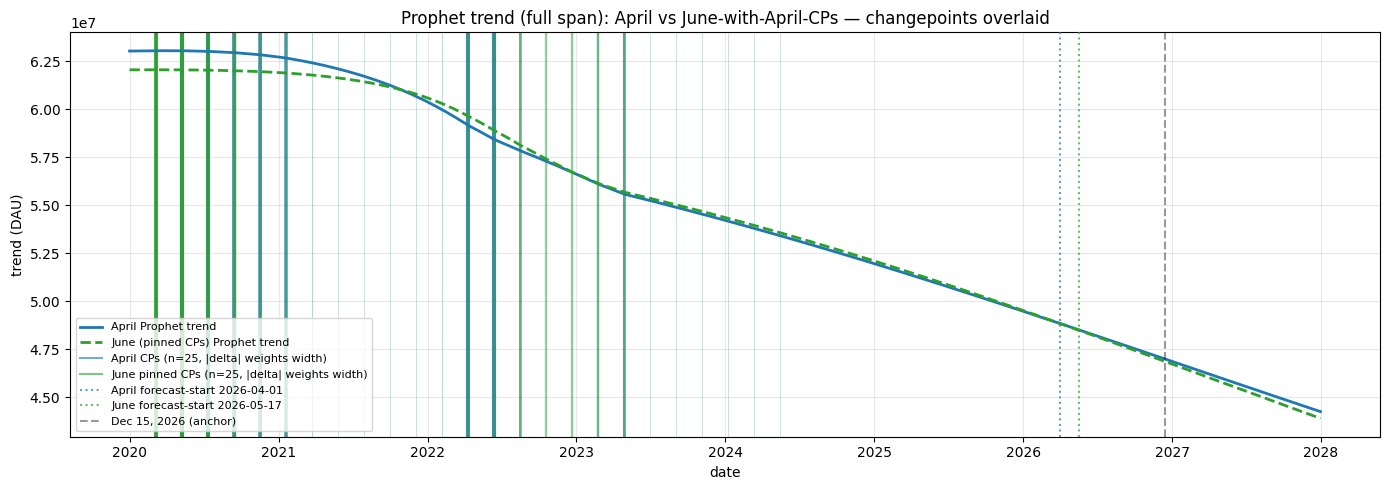


April trend @ 2026-12-15:                   46,982,768
June (pinned CPs) trend @ 2026-12-15:       46,854,242
Trend gap (June pinned − April):            -128,526

April top 5 changepoints by |delta|:
      date  delta
2022-06-13      2
2020-07-11     -2
2022-04-10      2
2020-05-08     -2
2020-09-12     -2

June (pinned to April CPs) top 5 changepoints by |delta|:
      date  delta
2020-05-08     -3
2020-03-05     -3
2020-07-11     -2
2020-09-12     -2
2022-06-13      2


In [10]:
# [plot-trend-pinned-fullspan]
# Full-timeline trend chart for the pinned comparison, analogous to the part-one
# plot-trend cell. The two models share identical changepoint dates by construction,
# so we mark them once (in black) and color the |delta| weights separately for April
# and June-pinned to surface how much each delta moved.

fig, ax = plt.subplots(figsize=(14, 5))

apr_trend_full = apr_pred_by_date["trend"]
jun_pin_trend_full = jun_pinned_pred_by_date["trend"]

ax.plot(apr_trend_full.index, apr_trend_full.values, color="tab:blue", lw=2, label="April Prophet trend", zorder=3)
ax.plot(jun_pin_trend_full.index, jun_pin_trend_full.values, color="tab:green", lw=2, ls="--",
        label="June (pinned CPs) Prophet trend", zorder=3)


def plot_changepoints(ax, prophet_m, color, label):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    abs_deltas = np.abs(deltas)
    max_abs = abs_deltas.max() if abs_deltas.max() > 0 else 1.0
    for ds, d in zip(cps, deltas):
        weight = abs(d) / max_abs
        alpha = 0.15 + 0.7 * weight
        lw = 0.6 + 2.4 * weight
        ax.axvline(ds, color=color, ls="-", alpha=alpha, lw=lw, zorder=2)
    ax.axvline(cps.iloc[0], color=color, ls="-", alpha=0.6, lw=1.5,
               label=f"{label} CPs (n={len(cps)}, |delta| weights width)")


plot_changepoints(ax, apr_m, "tab:blue", "April")
plot_changepoints(ax, jun_pinned_m, "tab:green", "June pinned")

ax.axvline(apr_mz.forecast_dates[0], color="tab:blue",  ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(jun_mz.forecast_dates[0], color="tab:green", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026 (anchor)", zorder=4)

ax.set_title("Prophet trend (full span): April vs June-with-April-CPs — changepoints overlaid")
ax.set_ylabel("trend (DAU)")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

anchor = pd.Timestamp("2026-12-15")
print(f"\nApril trend @ {anchor.date()}:               {apr_trend_full.loc[anchor]:>14,.0f}")
print(f"June (pinned CPs) trend @ {anchor.date()}:   {jun_pin_trend_full.loc[anchor]:>14,.0f}")
print(f"Trend gap (June pinned − April):            {(jun_pin_trend_full.loc[anchor] - apr_trend_full.loc[anchor]):+,.0f}")


def top_changepoints(prophet_m, n=5):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    rows = pd.DataFrame({"date": cps.values, "delta": deltas})
    rows["abs_delta"] = rows["delta"].abs()
    return rows.sort_values("abs_delta", ascending=False).head(n)[["date","delta"]]


print("\nApril top 5 changepoints by |delta|:")
print(top_changepoints(apr_m).to_string(index=False))
print("\nJune (pinned to April CPs) top 5 changepoints by |delta|:")
print(top_changepoints(jun_pinned_m).to_string(index=False))


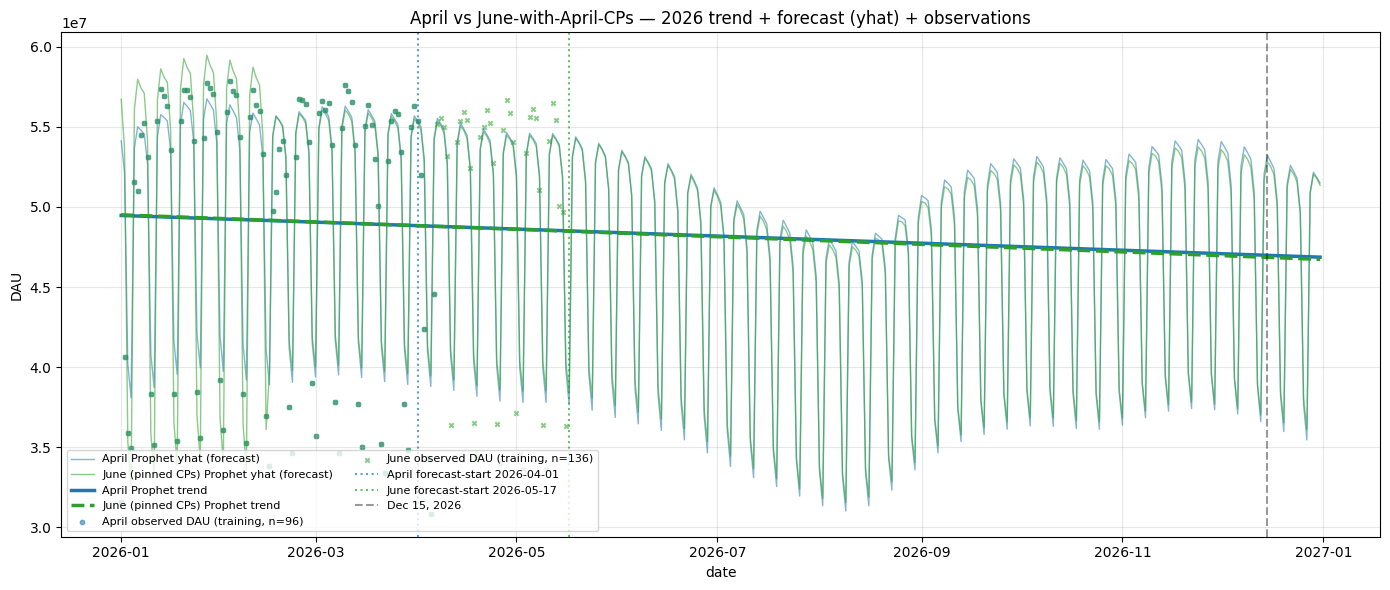


At 2026-12-15:
  April trend:                           46,982,768
  June (pinned CPs) trend:               46,854,242  (vs April: -128,526)
  April yhat (forecast):                 53,231,186
  June (pinned CPs) yhat (forecast):     52,824,664  (vs April: -406,522)


In [11]:
# [plot-trend-pinned-with-forecast]
# 2026-focused chart comparing the April fit to the June fit with April's changepoint
# dates pinned in. Shows:
#   - Trends from both models (bold solid lines).
#   - Full Prophet forecasts (yhat) from both models (thinner lines).
#   - Observed historical DAU for 2026 (scatter, where training data overlaps the window).
# Only the original April changepoint dates are marked, since the pinned June fit by
# construction uses the same set.

ZOOM_START = pd.Timestamp("2026-01-01")
ZOOM_END   = pd.Timestamp("2026-12-31")

apr_trend_z = apr_pred_by_date.loc[ZOOM_START:ZOOM_END, "trend"]
jun_pin_trend_z = jun_pinned_pred_by_date.loc[ZOOM_START:ZOOM_END, "trend"]
apr_yhat_z = apr_pred_by_date.loc[ZOOM_START:ZOOM_END, "yhat"]
jun_pin_yhat_z = jun_pinned_pred_by_date.loc[ZOOM_START:ZOOM_END, "yhat"]

# Observed (training) DAU within the zoom window. Both mz objects store raw historical
# values via `raw_historical_data` (indexed 0..n-1, paired with `historical_dates`).
apr_obs = pd.DataFrame({"ds": list(apr_mz.historical_dates),
                        "y":  list(apr_mz.raw_historical_data)})
jun_obs = pd.DataFrame({"ds": list(jun_mz.historical_dates),
                        "y":  list(jun_mz.raw_historical_data)})
apr_obs_z = apr_obs[(apr_obs["ds"] >= ZOOM_START) & (apr_obs["ds"] <= ZOOM_END)]
jun_obs_z = jun_obs[(jun_obs["ds"] >= ZOOM_START) & (jun_obs["ds"] <= ZOOM_END)]

fig, ax = plt.subplots(figsize=(14, 6))

# Forecast (yhat) curves first (thinner) so the trend lines sit on top.
ax.plot(apr_yhat_z.index, apr_yhat_z.values, color="tab:blue",  lw=1.0, alpha=0.55,
        label="April Prophet yhat (forecast)")
ax.plot(jun_pin_yhat_z.index, jun_pin_yhat_z.values, color="tab:green", lw=1.0, alpha=0.55,
        label="June (pinned CPs) Prophet yhat (forecast)")

# Trend curves bolded.
ax.plot(apr_trend_z.index, apr_trend_z.values, color="tab:blue",  lw=2.5,
        label="April Prophet trend")
ax.plot(jun_pin_trend_z.index, jun_pin_trend_z.values, color="tab:green", lw=2.5, ls="--",
        label="June (pinned CPs) Prophet trend")

# Observed historical DAU for the 2026 window (training-data observations).
ax.scatter(apr_obs_z["ds"], apr_obs_z["y"], color="tab:blue",  s=10, alpha=0.55,
           label=f"April observed DAU (training, n={len(apr_obs_z)})")
ax.scatter(jun_obs_z["ds"], jun_obs_z["y"], color="tab:green", s=10, alpha=0.55, marker="x",
           label=f"June observed DAU (training, n={len(jun_obs_z)})")

# Reference markers.
ax.axvline(apr_mz.forecast_dates[0], color="tab:blue",  ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}")
ax.axvline(jun_mz.forecast_dates[0], color="tab:green", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}")
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026")

# April changepoints (pinned and used by both fits in this plot). Most fall pre-2026 so
# only the latest one or two land inside the zoom window.
for ds in apr_changepoint_dates:
    if ZOOM_START <= ds <= ZOOM_END:
        ax.axvline(ds, color="k", ls="-", alpha=0.15, lw=1.0)

ax.set_title("April vs June-with-April-CPs — 2026 trend + forecast (yhat) + observations")
ax.set_ylabel("DAU")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Numerics
anchor = pd.Timestamp("2026-12-15")
print(f"\nAt {anchor.date()}:")
print(f"  April trend:                       {apr_trend_z.loc[anchor]:>14,.0f}")
print(f"  June (pinned CPs) trend:           {jun_pin_trend_z.loc[anchor]:>14,.0f}  "
      f"(vs April: {jun_pin_trend_z.loc[anchor]-apr_trend_z.loc[anchor]:+,.0f})")
print(f"  April yhat (forecast):             {apr_yhat_z.loc[anchor]:>14,.0f}")
print(f"  June (pinned CPs) yhat (forecast): {jun_pin_yhat_z.loc[anchor]:>14,.0f}  "
      f"(vs April: {jun_pin_yhat_z.loc[anchor]-apr_yhat_z.loc[anchor]:+,.0f})")


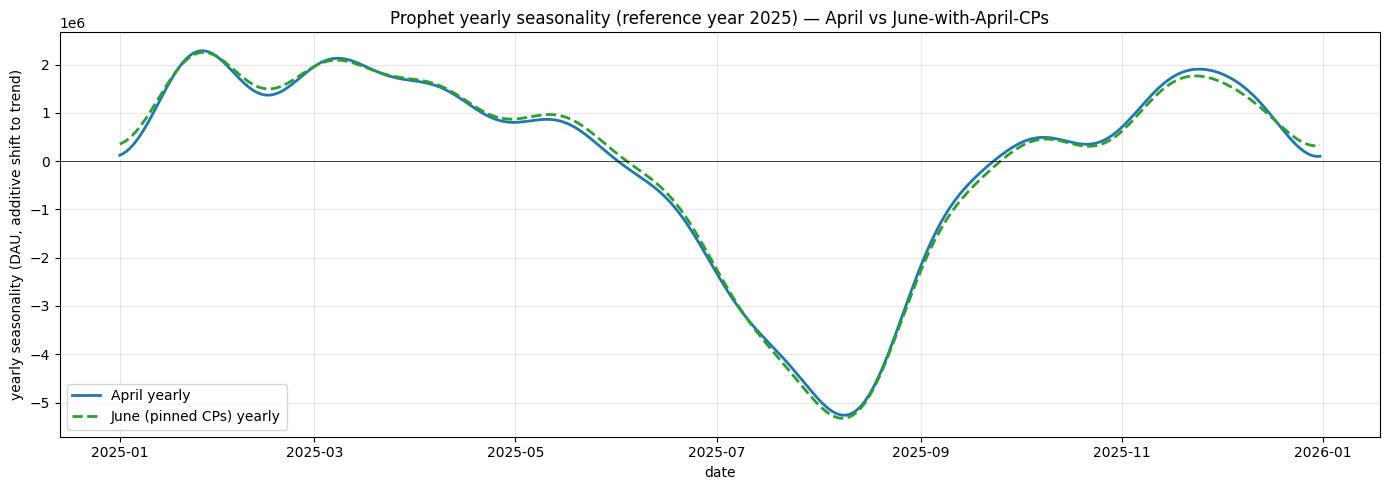


April yearly range over 2025: -5,263,708 DAU  →  +2,287,291 DAU
June (pinned CPs) yearly:     -5,328,067 DAU  →  +2,252,867 DAU

For scale: April mean 2025 trend = 50,728,535 DAU; June pinned = 50,824,387
  April yearly range as % of trend:           -10.38% → +4.51%
  June (pinned) yearly range as % of trend:   -10.48% → +4.43%


In [12]:
# [plot-yearly-pinned]
# Yearly seasonality: April vs June (changepoints pinned to April's dates).
# Both models use additive mode, so values are raw DAU offsets from trend.

ref_year_start = pd.Timestamp("2025-01-01")
ref_year_end   = pd.Timestamp("2025-12-31")

apr_yearly = apr_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]
jun_pin_yearly = jun_pinned_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]

mode_apr = apr_m.seasonality_mode
mode_pin = jun_pinned_m.seasonality_mode
assert mode_apr == mode_pin == "additive", \
    f"Expected additive mode for both; got April={mode_apr}, June-pinned={mode_pin}"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(apr_yearly.index, apr_yearly.values, color="tab:blue", lw=2, label="April yearly")
ax.plot(jun_pin_yearly.index, jun_pin_yearly.values, color="tab:green", lw=2, ls="--",
        label="June (pinned CPs) yearly")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Prophet yearly seasonality (reference year 2025) — April vs June-with-April-CPs")
ax.set_ylabel("yearly seasonality (DAU, additive shift to trend)")
ax.set_xlabel("date")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nApril yearly range over 2025: {apr_yearly.min():>+,.0f} DAU  →  {apr_yearly.max():>+,.0f} DAU")
print(f"June (pinned CPs) yearly:     {jun_pin_yearly.min():>+,.0f} DAU  →  {jun_pin_yearly.max():>+,.0f} DAU")
apr_trend_mean = apr_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
jun_pin_trend_mean = jun_pinned_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
print(f"\nFor scale: April mean 2025 trend = {apr_trend_mean:,.0f} DAU; June pinned = {jun_pin_trend_mean:,.0f}")
print(f"  April yearly range as % of trend:           {apr_yearly.min()/apr_trend_mean*100:+.2f}% → {apr_yearly.max()/apr_trend_mean*100:+.2f}%")
print(f"  June (pinned) yearly range as % of trend:   {jun_pin_yearly.min()/jun_pin_trend_mean*100:+.2f}% → {jun_pin_yearly.max()/jun_pin_trend_mean*100:+.2f}%")


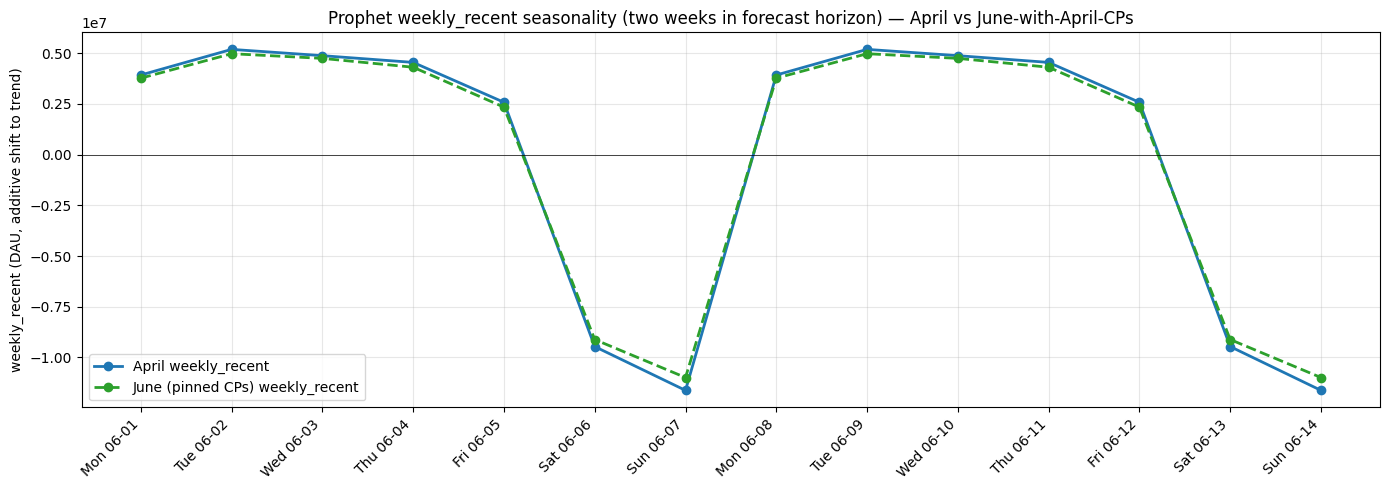


April weekly_recent amplitude (max−min over 7d):           +16,800,990 DAU
June (pinned CPs) weekly_recent amplitude (max−min over 7d): +15,954,986 DAU

For scale (trend over plot window):
  April:               48,353,565 DAU; weekly amplitude as % of trend: 34.75%
  June (pinned CPs):   48,323,013 DAU; weekly amplitude as % of trend: 33.02%


In [13]:
# [plot-weekly-pinned]
# Weekly_recent seasonality: April vs June (changepoints pinned to April's dates).
# Additive mode → values are raw DAU offsets from trend.

week_start = pd.Timestamp("2026-06-01")  # Monday in forecast horizon
two_weeks_end = week_start + pd.Timedelta(days=13)

apr_weekly = apr_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]
jun_pin_weekly = jun_pinned_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]

fig, ax = plt.subplots(figsize=(14, 5))
day_labels = [(week_start + pd.Timedelta(days=i)).strftime("%a %m-%d") for i in range(len(apr_weekly))]
ax.plot(range(len(apr_weekly)), apr_weekly.values, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
ax.plot(range(len(jun_pin_weekly)), jun_pin_weekly.values, color="tab:green", marker="o", lw=2, ls="--",
        label="June (pinned CPs) weekly_recent")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(len(apr_weekly)))
ax.set_xticklabels(day_labels, rotation=45, ha="right")
ax.set_title("Prophet weekly_recent seasonality (two weeks in forecast horizon) — April vs June-with-April-CPs")
ax.set_ylabel("weekly_recent (DAU, additive shift to trend)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

apr_amp = apr_weekly.iloc[:7].max() - apr_weekly.iloc[:7].min()
pin_amp = jun_pin_weekly.iloc[:7].max() - jun_pin_weekly.iloc[:7].min()
print(f"\nApril weekly_recent amplitude (max−min over 7d):           {apr_amp:>+,.0f} DAU")
print(f"June (pinned CPs) weekly_recent amplitude (max−min over 7d): {pin_amp:>+,.0f} DAU")

apr_trend_mean = apr_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
pin_trend_mean = jun_pinned_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
print(f"\nFor scale (trend over plot window):")
print(f"  April:               {apr_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {apr_amp/apr_trend_mean*100:.2f}%")
print(f"  June (pinned CPs):   {pin_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {pin_amp/pin_trend_mean*100:.2f}%")


Identity check: yhat gap == trend gap + yearly gap + weekly_recent gap + weekly_historical gap
  max |sum_check − yhat gap| over horizon: 0.000000
  mean |sum_check − yhat gap|:             0.000000
(If those are ~0 the decomposition is exact and any narrative based on it is rigorous.)

=== Component breakdown of (April − June_pinned) at 2026-12-15 ===
                        April  June_pinned  Gap (Apr−Pin)
trend             +46,982,768  +46,854,242       +128,526
yearly             +1,067,864   +1,003,035        +64,829
weekly_recent      +5,180,554   +4,967,388       +213,166
weekly_historical          +0           +0             +0
yhat              +53,231,186  +52,824,664       +406,522

Trend gap            : +128,526  ( +31.6% of yhat gap)
Seasonality gap (sum): +277,996  ( +68.4% of yhat gap)
Yhat gap (total)     : +406,522

=== Per-component RMS contribution to the yhat gap (over full forecast horizon) ===
  trend               : RMS =    203,278   mean |gap| =    179,003   

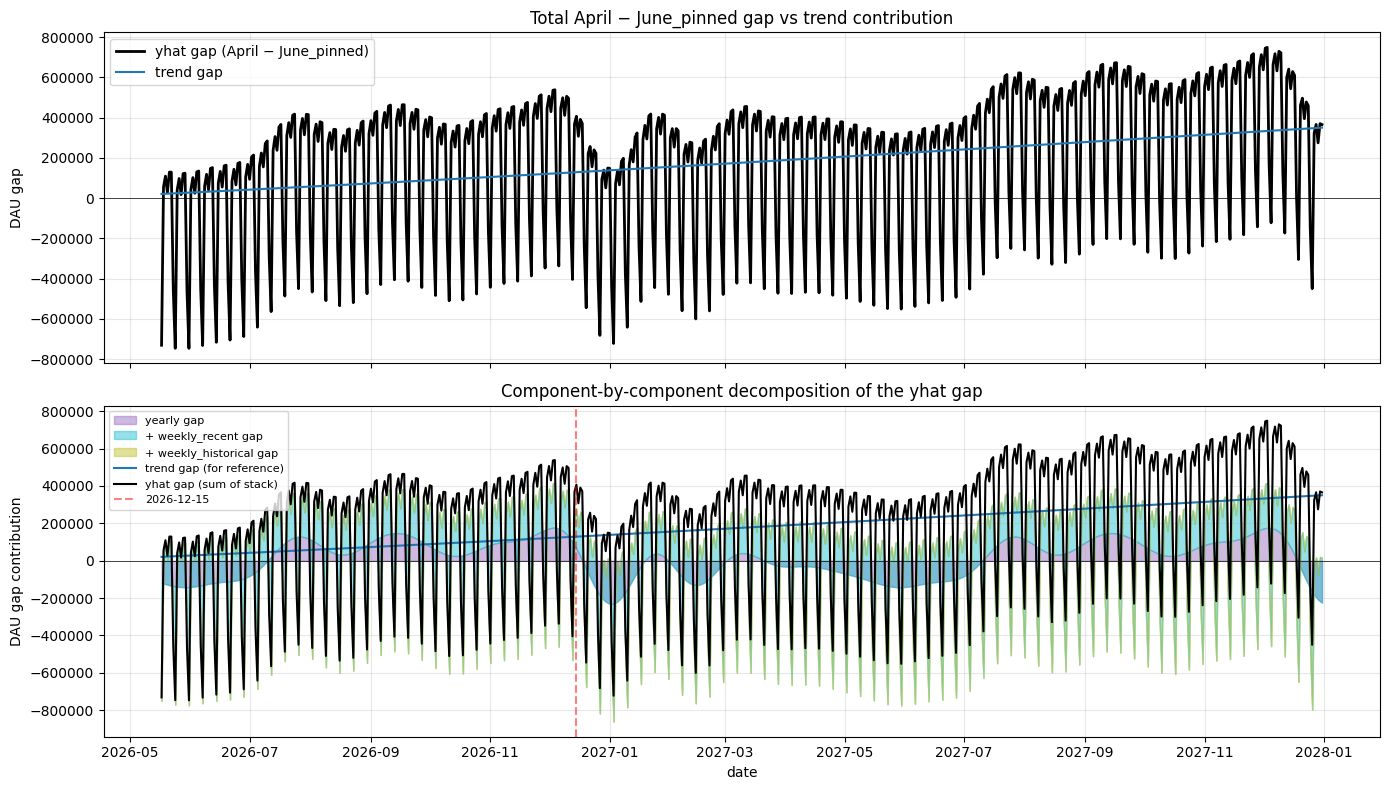

In [14]:
# [prove-seasonality-driver]
# Decompose the April-vs-June_pinned yhat gap into its additive components.
#
# Both Prophet models use additive seasonality_mode, no Prophet-level holidays added
# (Mozaic handles holiday detrending externally). So at every date:
#
#     yhat = trend + yearly + weekly_recent + weekly_historical
#
# (weekly_historical is zero in the forecast horizon by construction).
#
# Therefore the per-date gap decomposes exactly:
#
#     gap_yhat(d)   = (apr_yhat   - jun_pin_yhat)(d)
#                   = gap_trend(d) + gap_yearly(d) + gap_weekly_recent(d) + gap_weekly_historical(d)
#
# We compute each piece over the forecast horizon and plot how much each contributes
# to the overall yhat gap. If trend gap dwarfs seasonality gaps -> trend is the driver.
# If seasonality gaps dwarf trend gap -> seasonality is the driver.

FORECAST_START = max(apr_mz.forecast_dates[0], jun_mz.forecast_dates[0])
FORECAST_END   = pd.Timestamp("2027-12-31")
horizon = pd.date_range(FORECAST_START, FORECAST_END, freq="D")

components = ["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]
apr_comp = apr_pred_by_date.loc[horizon, components].copy()
pin_comp = jun_pinned_pred_by_date.loc[horizon, components].copy()

gap = (apr_comp - pin_comp).copy()  # April − June_pinned, per component, per date
gap["sum_check"] = gap["trend"] + gap["yearly"] + gap["weekly_recent"] + gap["weekly_historical"]
gap["sum_minus_yhat"] = gap["sum_check"] - gap["yhat"]

print("Identity check: yhat gap == trend gap + yearly gap + weekly_recent gap + weekly_historical gap")
print(f"  max |sum_check − yhat gap| over horizon: {gap['sum_minus_yhat'].abs().max():.6f}")
print(f"  mean |sum_check − yhat gap|:             {gap['sum_minus_yhat'].abs().mean():.6f}")
print("(If those are ~0 the decomposition is exact and any narrative based on it is rigorous.)")
print()

# Numeric table at the Dec 15 anchor.
anchor = pd.Timestamp("2026-12-15")
print(f"=== Component breakdown of (April − June_pinned) at {anchor.date()} ===")
table = pd.DataFrame({
    "April":          apr_comp.loc[anchor],
    "June_pinned":    pin_comp.loc[anchor],
    "Gap (Apr−Pin)":  apr_comp.loc[anchor] - pin_comp.loc[anchor],
})
print(table.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()
trend_gap_anchor = gap.loc[anchor, "trend"]
seas_gap_anchor = gap.loc[anchor, "yearly"] + gap.loc[anchor, "weekly_recent"] + gap.loc[anchor, "weekly_historical"]
yhat_gap_anchor = gap.loc[anchor, "yhat"]
print(f"Trend gap            : {trend_gap_anchor:>+,.0f}  ({trend_gap_anchor/yhat_gap_anchor*100:>+6.1f}% of yhat gap)")
print(f"Seasonality gap (sum): {seas_gap_anchor:>+,.0f}  ({seas_gap_anchor/yhat_gap_anchor*100:>+6.1f}% of yhat gap)")
print(f"Yhat gap (total)     : {yhat_gap_anchor:>+,.0f}")

# Per-component contribution to *the gap* averaged over the whole forecast horizon.
# "% of |yhat gap|" using mean |gap_yhat| as the denominator gives an apples-to-apples
# size for each component's contribution, sign-agnostic.
mean_abs_yhat_gap = gap["yhat"].abs().mean()
print()
print("=== Per-component RMS contribution to the yhat gap (over full forecast horizon) ===")
for comp in ["trend","yearly","weekly_recent","weekly_historical"]:
    rms = (gap[comp] ** 2).mean() ** 0.5
    mean_abs = gap[comp].abs().mean()
    print(f"  {comp:20s}: RMS = {rms:>10,.0f}   mean |gap| = {mean_abs:>10,.0f}   "
          f"({mean_abs/mean_abs_yhat_gap*100:>5.1f}% of mean |yhat gap|)")

# Plot: each component's signed contribution to (Apr − Pin) over the forecast horizon.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(gap.index, gap["yhat"], color="black", lw=2.0, label="yhat gap (April − June_pinned)")
axes[0].plot(gap.index, gap["trend"], color="tab:blue", lw=1.5, label="trend gap")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_title("Total April − June_pinned gap vs trend contribution")
axes[0].set_ylabel("DAU gap")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Stacked area for the seasonality components, with trend as a line for reference.
axes[1].fill_between(gap.index, 0, gap["yearly"], color="tab:purple", alpha=0.45, label="yearly gap")
axes[1].fill_between(gap.index, gap["yearly"], gap["yearly"] + gap["weekly_recent"], color="tab:cyan",
                     alpha=0.45, label="+ weekly_recent gap")
axes[1].fill_between(gap.index, gap["yearly"] + gap["weekly_recent"],
                     gap["yearly"] + gap["weekly_recent"] + gap["weekly_historical"],
                     color="tab:olive", alpha=0.45, label="+ weekly_historical gap")
axes[1].plot(gap.index, gap["trend"], color="tab:blue", lw=1.5, label="trend gap (for reference)")
axes[1].plot(gap.index, gap["yhat"], color="black", lw=1.5, label="yhat gap (sum of stack)")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(anchor, color="r", ls="--", alpha=0.5, label=f"{anchor.date()}")
axes[1].set_title("Component-by-component decomposition of the yhat gap")
axes[1].set_ylabel("DAU gap contribution")
axes[1].set_xlabel("date")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 28-day moving average decomposition (natural changepoints)

The forecast gap reported to leadership is on a 28-day moving-average basis. The 28-day MA spans
exactly four full weekly cycles, so `weekly_recent` (a pure 7-day periodic) integrates to ~zero
under a centered 28-day MA — what survives are the slow-moving components: **trend** and
**yearly** seasonality.

Since the rolling mean is linear, the additive decomposition carries over exactly:

```
MA28(yhat) = MA28(trend) + MA28(yearly) + MA28(weekly_recent) + MA28(weekly_historical)
```

The plot and table below compare April vs June (each fit with its own natural changepoints — no
pinning). Component gaps are computed on the MA-smoothed series so we can read directly which
slow-moving piece drives the 28-day MA gap.


Identity check on 28-day MA series:
  max |sum_check − MA(yhat) gap|: 0.000000
  mean |residual|:                0.000000
(~0 confirms the decomposition transfers to the smoothed series.)

=== Raw daily vs 28-day MA gap at 2026-12-15 ===
  raw daily yhat gap (April − June): +420,627
  MA28      yhat gap (April − June): +184,311

=== MA28 component breakdown of (April − June) at 2026-12-15 ===
                     April MA     June MA      Gap
trend             +46,986,376 +46,840,728 +145,647
yearly             +1,045,899  +1,007,235  +38,663
weekly_recent              -0          -0       -0
weekly_historical          +0          +0       +0
yhat              +48,032,274 +47,847,964 +184,311

  trend share:              +79.0% of MA yhat gap
  yearly share:             +21.0%
  weekly_recent share:       -0.0%  (should be tiny — averaged over 4 cycles)
  weekly_historical share:   +0.0%  (zero in horizon by construction)

=== Per-component contribution to MA28 yhat gap (full forecast 

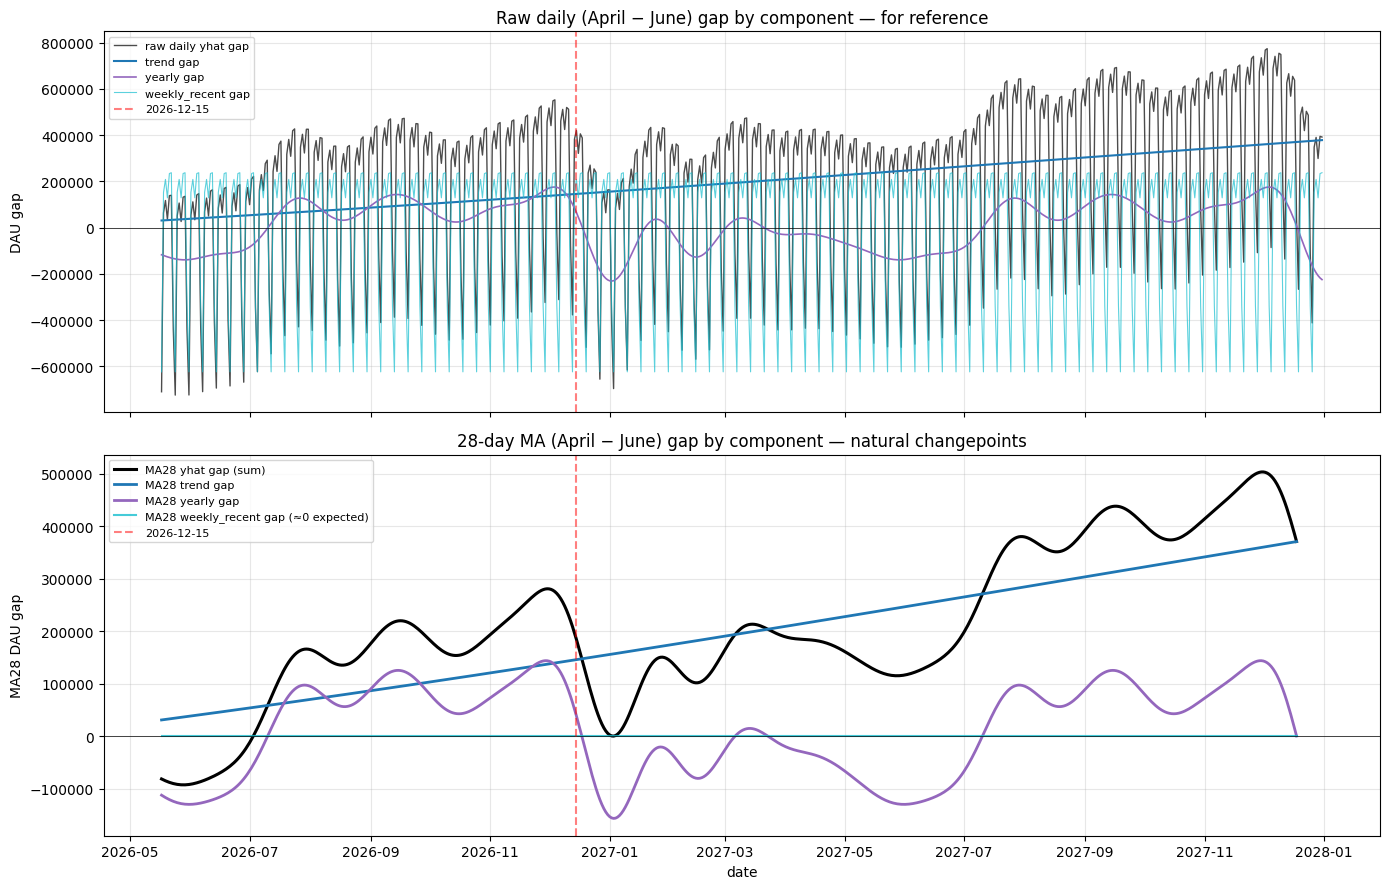

In [15]:
# [ma28-decompose-natural]
# 28-day moving-average decomposition of (April - June) using each fit's natural changepoints.
#
# The 28-day MA is exactly four weekly cycles, so a centered 28-day MA cancels the weekly
# seasonality almost perfectly. We use a CENTERED 28-day window (window=28, center=True,
# min_periods=28) so MA(d) reflects what a viewer at date d would see on the smoothed series.
# Since rolling mean is linear, the identity yhat = trend + yearly + weekly_recent + weekly_historical
# survives smoothing: MA(yhat) = MA(trend) + MA(yearly) + MA(weekly_recent) + MA(weekly_historical).

MA_WINDOW = 28

components = ["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]

def ma28(df):
    return df[components].rolling(window=MA_WINDOW, center=True, min_periods=MA_WINDOW).mean()

apr_ma = ma28(apr_pred_by_date)
jun_ma = ma28(jun_pred_by_date)

# Restrict to the forecast horizon where both fits produce yhat.
FORECAST_START = max(apr_mz.forecast_dates[0], jun_mz.forecast_dates[0])
FORECAST_END   = pd.Timestamp("2027-12-31")
horizon = pd.date_range(FORECAST_START, FORECAST_END, freq="D")

apr_ma_h = apr_ma.reindex(horizon).copy()
jun_ma_h = jun_ma.reindex(horizon).copy()
gap_ma = (apr_ma_h - jun_ma_h).copy()  # April − June, per component, on the MA-smoothed series

# Identity check on MA series.
sum_check = gap_ma["trend"] + gap_ma["yearly"] + gap_ma["weekly_recent"] + gap_ma["weekly_historical"]
sum_residual = (sum_check - gap_ma["yhat"]).abs()
print("Identity check on 28-day MA series:")
print(f"  max |sum_check − MA(yhat) gap|: {sum_residual.max():.6f}")
print(f"  mean |residual|:                {sum_residual.mean():.6f}")
print("(~0 confirms the decomposition transfers to the smoothed series.)")
print()

# Compare raw daily gap vs MA gap at Dec 15.
anchor = pd.Timestamp("2026-12-15")
raw_gap_anchor = apr_pred_by_date.loc[anchor, "yhat"] - jun_pred_by_date.loc[anchor, "yhat"]
ma_gap_anchor  = gap_ma.loc[anchor, "yhat"]
print(f"=== Raw daily vs 28-day MA gap at {anchor.date()} ===")
print(f"  raw daily yhat gap (April − June): {raw_gap_anchor:>+,.0f}")
print(f"  MA28      yhat gap (April − June): {ma_gap_anchor:>+,.0f}")
print()

# Component breakdown of the MA gap at Dec 15.
print(f"=== MA28 component breakdown of (April − June) at {anchor.date()} ===")
table = pd.DataFrame({
    "April MA":  apr_ma_h.loc[anchor],
    "June MA":   jun_ma_h.loc[anchor],
    "Gap":       gap_ma.loc[anchor],
})
print(table.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()

trend_share  = gap_ma.loc[anchor, "trend"]  / gap_ma.loc[anchor, "yhat"]
yearly_share = gap_ma.loc[anchor, "yearly"] / gap_ma.loc[anchor, "yhat"]
wrec_share   = gap_ma.loc[anchor, "weekly_recent"] / gap_ma.loc[anchor, "yhat"]
whist_share  = gap_ma.loc[anchor, "weekly_historical"] / gap_ma.loc[anchor, "yhat"]
print(f"  trend share:             {trend_share*100:>+6.1f}% of MA yhat gap")
print(f"  yearly share:            {yearly_share*100:>+6.1f}%")
print(f"  weekly_recent share:     {wrec_share*100:>+6.1f}%  (should be tiny — averaged over 4 cycles)")
print(f"  weekly_historical share: {whist_share*100:>+6.1f}%  (zero in horizon by construction)")
print()

# Horizon-averaged contributions on the MA-smoothed series.
gap_ma_valid = gap_ma.dropna(subset=["yhat"])
mean_abs_yhat_gap = gap_ma_valid["yhat"].abs().mean()
print("=== Per-component contribution to MA28 yhat gap (full forecast horizon, MA-valid dates) ===")
for comp in ["trend", "yearly", "weekly_recent", "weekly_historical"]:
    rms = (gap_ma_valid[comp] ** 2).mean() ** 0.5
    mean_abs = gap_ma_valid[comp].abs().mean()
    pct = mean_abs / mean_abs_yhat_gap * 100 if mean_abs_yhat_gap else 0
    print(f"  {comp:20s}: RMS = {rms:>10,.0f}   mean |gap| = {mean_abs:>10,.0f}   ({pct:>5.1f}% of mean |MA yhat gap|)")
print(f"  {'mean |MA yhat gap|':20s}: {mean_abs_yhat_gap:>10,.0f}")
print()

# Side-by-side raw-vs-MA component contribution.
raw_gap = (apr_pred_by_date.reindex(horizon)[components]
           - jun_pred_by_date.reindex(horizon)[components])
print("=== Raw daily vs MA28: mean |component gap| (full horizon) ===")
print(f"  {'component':20s} {'raw mean |gap|':>18s} {'MA28 mean |gap|':>18s} {'ratio MA/raw':>14s}")
for comp in ["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]:
    raw_m = raw_gap[comp].abs().mean()
    ma_m = gap_ma_valid[comp].abs().mean()
    ratio = ma_m / raw_m if raw_m else float("nan")
    print(f"  {comp:20s} {raw_m:>18,.0f} {ma_m:>18,.0f} {ratio:>13.2%}")
print("(weekly_recent ratio should approach 0 — 4 cycles cancel under MA28.)")
print()

# Plot: side-by-side raw-daily-gap vs MA28-gap decomposition over the forecast horizon.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top panel: raw daily gap decomposition for reference.
raw_yhat = raw_gap["yhat"]
raw_trend = raw_gap["trend"]
raw_yearly = raw_gap["yearly"]
raw_wrec = raw_gap["weekly_recent"]
raw_whist = raw_gap["weekly_historical"]

axes[0].plot(raw_yhat.index, raw_yhat, color="black", lw=1.0, alpha=0.7, label="raw daily yhat gap")
axes[0].plot(raw_trend.index, raw_trend, color="tab:blue", lw=1.5, label="trend gap")
axes[0].plot(raw_yearly.index, raw_yearly, color="tab:purple", lw=1.2, label="yearly gap")
axes[0].plot(raw_wrec.index, raw_wrec, color="tab:cyan", lw=0.8, alpha=0.7, label="weekly_recent gap")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axvline(anchor, color="r", ls="--", alpha=0.5, label=f"{anchor.date()}")
axes[0].set_title("Raw daily (April − June) gap by component — for reference")
axes[0].set_ylabel("DAU gap")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(alpha=0.3)

# Bottom panel: MA28 gap decomposition — the main result.
axes[1].plot(gap_ma.index, gap_ma["yhat"], color="black", lw=2.2, label="MA28 yhat gap (sum)")
axes[1].plot(gap_ma.index, gap_ma["trend"], color="tab:blue", lw=2.0, label="MA28 trend gap")
axes[1].plot(gap_ma.index, gap_ma["yearly"], color="tab:purple", lw=2.0, label="MA28 yearly gap")
axes[1].plot(gap_ma.index, gap_ma["weekly_recent"], color="tab:cyan", lw=1.5, alpha=0.8,
             label="MA28 weekly_recent gap (≈0 expected)")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(anchor, color="r", ls="--", alpha=0.5, label=f"{anchor.date()}")
axes[1].set_title("28-day MA (April − June) gap by component — natural changepoints")
axes[1].set_ylabel("MA28 DAU gap")
axes[1].set_xlabel("date")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Identity check on 28-day MA series (pinned CPs):
  max |sum_check − MA(yhat) gap|: 0.000000

=== MA28 component breakdown (April − June_pinned) at 2026-12-15 ===
                     April MA  June_pinned MA  Gap (pinned)  Gap (natural)  Δ (pin − natural)
trend             +46,986,376     +46,858,114      +128,262       +145,647            -17,385
yearly             +1,045,899      +1,007,686       +38,212        +38,663               -451
weekly_recent              -0              -0            -0             -0                 -0
weekly_historical          +0              +0            +0             +0                 +0
yhat              +48,032,274     +47,865,800      +166,474       +184,311            -17,836

  MA28 yhat gap, natural CPs:  +184,311
  MA28 yhat gap, pinned CPs:   +166,474
  shift from pinning:           -17,836

  MA28 trend gap, natural CPs: +145,647
  MA28 trend gap, pinned CPs:  +128,262
  shift in trend gap:           -17,385

  Pinning resolves +11.9% of th

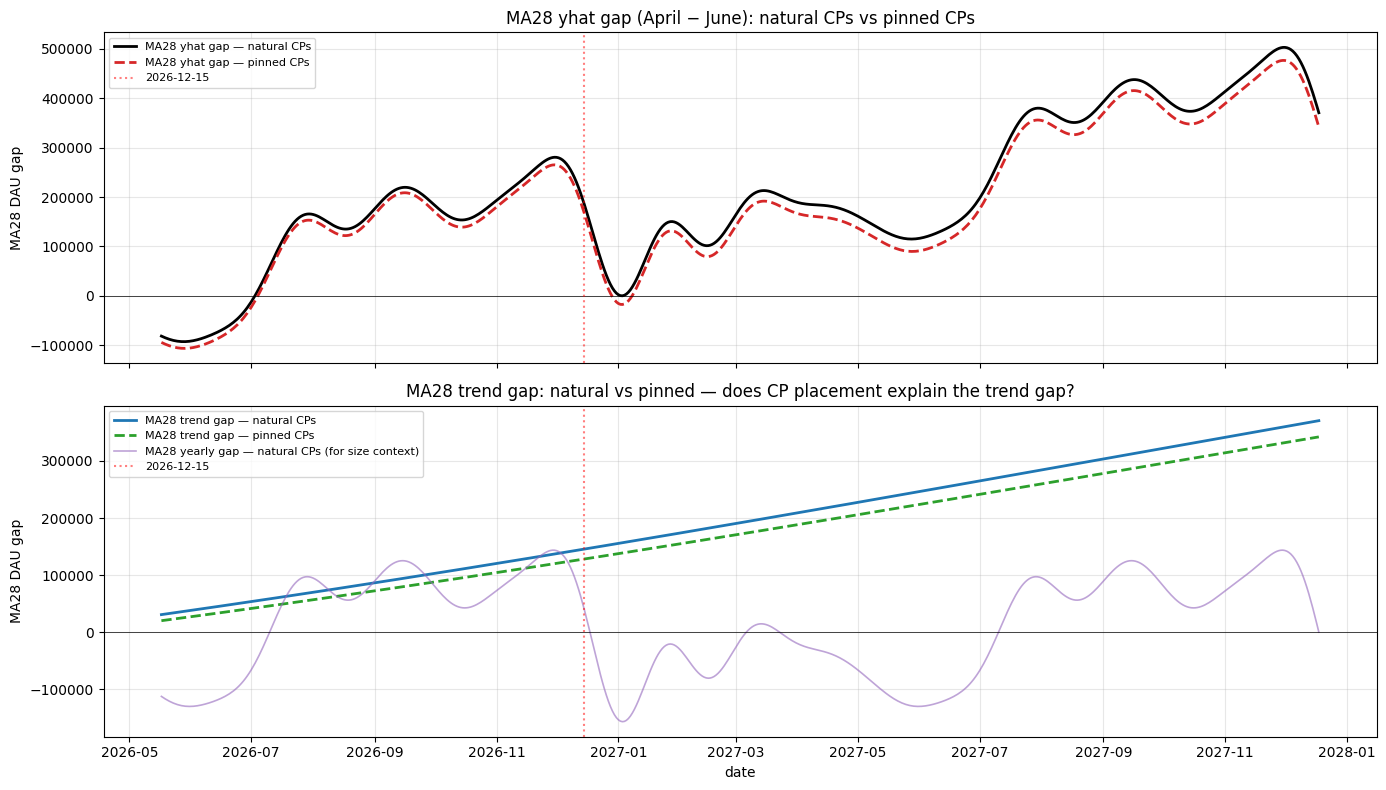

In [16]:
# [ma28-decompose-pinned]
# Repeat the 28-day MA decomposition with June's changepoints PINNED to April's dates.
# If the MA28 trend gap shrinks substantially vs the natural-CP version, then CP placement
# was driving the trend gap. If it barely moves, then the trend gap lives in the deltas
# fit at the existing CP dates — i.e., the recent slope difference is being absorbed into
# the trend extending from the last 2022 changepoint regardless of where new CPs could go.

apr_ma_p = ma28(apr_pred_by_date)
jun_pin_ma = ma28(jun_pinned_pred_by_date)

apr_ma_h_p = apr_ma_p.reindex(horizon).copy()
jun_pin_ma_h = jun_pin_ma.reindex(horizon).copy()
gap_ma_pinned = (apr_ma_h_p - jun_pin_ma_h).copy()

# Identity check on the pinned MA series.
sum_check_p = (gap_ma_pinned["trend"] + gap_ma_pinned["yearly"]
               + gap_ma_pinned["weekly_recent"] + gap_ma_pinned["weekly_historical"])
sum_residual_p = (sum_check_p - gap_ma_pinned["yhat"]).abs()
print("Identity check on 28-day MA series (pinned CPs):")
print(f"  max |sum_check − MA(yhat) gap|: {sum_residual_p.max():.6f}")
print()

# Component breakdown at Dec 15.
print(f"=== MA28 component breakdown (April − June_pinned) at {anchor.date()} ===")
table_p = pd.DataFrame({
    "April MA":         apr_ma_h_p.loc[anchor],
    "June_pinned MA":   jun_pin_ma_h.loc[anchor],
    "Gap (pinned)":     gap_ma_pinned.loc[anchor],
    "Gap (natural)":    gap_ma.loc[anchor],
    "Δ (pin − natural)":gap_ma_pinned.loc[anchor] - gap_ma.loc[anchor],
})
print(table_p.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()

yhat_gap_p = gap_ma_pinned.loc[anchor, "yhat"]
yhat_gap_n = gap_ma.loc[anchor, "yhat"]
print(f"  MA28 yhat gap, natural CPs:  {yhat_gap_n:>+,.0f}")
print(f"  MA28 yhat gap, pinned CPs:   {yhat_gap_p:>+,.0f}")
print(f"  shift from pinning:           {yhat_gap_p - yhat_gap_n:>+,.0f}")
print()
trend_gap_p = gap_ma_pinned.loc[anchor, "trend"]
trend_gap_n = gap_ma.loc[anchor, "trend"]
print(f"  MA28 trend gap, natural CPs: {trend_gap_n:>+,.0f}")
print(f"  MA28 trend gap, pinned CPs:  {trend_gap_p:>+,.0f}")
print(f"  shift in trend gap:           {trend_gap_p - trend_gap_n:>+,.0f}")
print()
if abs(trend_gap_n) > 1:
    pct_resolved = (1 - trend_gap_p / trend_gap_n) * 100
    print(f"  Pinning resolves {pct_resolved:>+5.1f}% of the natural-CP MA28 trend gap.")
    print(f"  ({'CP placement was the driver' if abs(pct_resolved) > 50 else 'CP placement is NOT the driver — deltas at fixed CPs absorb the slope difference'})")
print()

# Horizon-averaged for pinned.
gap_ma_pinned_valid = gap_ma_pinned.dropna(subset=["yhat"])
mean_abs_yhat_gap_p = gap_ma_pinned_valid["yhat"].abs().mean()
print("=== Per-component contribution to MA28 yhat gap (PINNED, full forecast horizon) ===")
for comp in ["trend", "yearly", "weekly_recent", "weekly_historical"]:
    mean_abs = gap_ma_pinned_valid[comp].abs().mean()
    pct = mean_abs / mean_abs_yhat_gap_p * 100 if mean_abs_yhat_gap_p else 0
    print(f"  {comp:20s}: mean |gap| = {mean_abs:>10,.0f}   ({pct:>5.1f}% of mean |MA yhat gap|)")
print(f"  {'mean |MA yhat gap|':20s}: {mean_abs_yhat_gap_p:>10,.0f}")
print()

# Side-by-side: natural vs pinned, trend-gap and yhat-gap on the smoothed series.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(gap_ma.index, gap_ma["yhat"], color="black", lw=2.0, label="MA28 yhat gap — natural CPs")
axes[0].plot(gap_ma_pinned.index, gap_ma_pinned["yhat"], color="tab:red", lw=2.0, ls="--",
             label="MA28 yhat gap — pinned CPs")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axvline(anchor, color="r", ls=":", alpha=0.5, label=f"{anchor.date()}")
axes[0].set_title("MA28 yhat gap (April − June): natural CPs vs pinned CPs")
axes[0].set_ylabel("MA28 DAU gap")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(gap_ma.index, gap_ma["trend"], color="tab:blue", lw=2.0, label="MA28 trend gap — natural CPs")
axes[1].plot(gap_ma_pinned.index, gap_ma_pinned["trend"], color="tab:green", lw=2.0, ls="--",
             label="MA28 trend gap — pinned CPs")
axes[1].plot(gap_ma.index, gap_ma["yearly"], color="tab:purple", lw=1.2, alpha=0.6,
             label="MA28 yearly gap — natural CPs (for size context)")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(anchor, color="r", ls=":", alpha=0.5, label=f"{anchor.date()}")
axes[1].set_title("MA28 trend gap: natural vs pinned — does CP placement explain the trend gap?")
axes[1].set_ylabel("MA28 DAU gap")
axes[1].set_xlabel("date")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Recent training tail — is the slope flip real?

The Prophet trend gap is driven by a slope flip in the last ~6 weeks of training data: April's
final 90-day slope was +66k DAU/day, June's is −24k/day. Before chasing this with parameters,
look at the data directly. If the recent downturn is a clean, sustained inflection, no Prophet
parameter will close the gap honestly — the data really moved. If it's a handful of anomalous
days dragging the slope, then the right move is to tighten `changepoint_prior_scale` so Prophet
resists over-fitting to that noise.

The plot below shows the last 90 days of each fit's training data (the values Prophet actually
fits — i.e. the holiday-detrended series), with a 28-day MA and an OLS slope fitted on the last
30 and last 60 days of each.


=== OLS slopes on holiday-detrended training tail ===
  April last 30d OLS slope:    -63,412 DAU/day  (start 2026-03-08 → end 2026-04-06)
  April last 60d OLS slope:     -7,826 DAU/day  (start 2026-02-06 → end 2026-04-06)
  April last 90d OLS slope:    -21,252 DAU/day  (start 2026-01-07 → end 2026-04-06)
  June  last 30d OLS slope:    +56,465 DAU/day  (start 2026-04-17 → end 2026-05-16)
  June  last 60d OLS slope:    -12,523 DAU/day  (start 2026-03-18 → end 2026-05-16)
  June  last 90d OLS slope:    -24,252 DAU/day  (start 2026-02-16 → end 2026-05-16)

April training end: 2026-04-06
June  training end: 2026-05-16
Days from April end to June end: 40


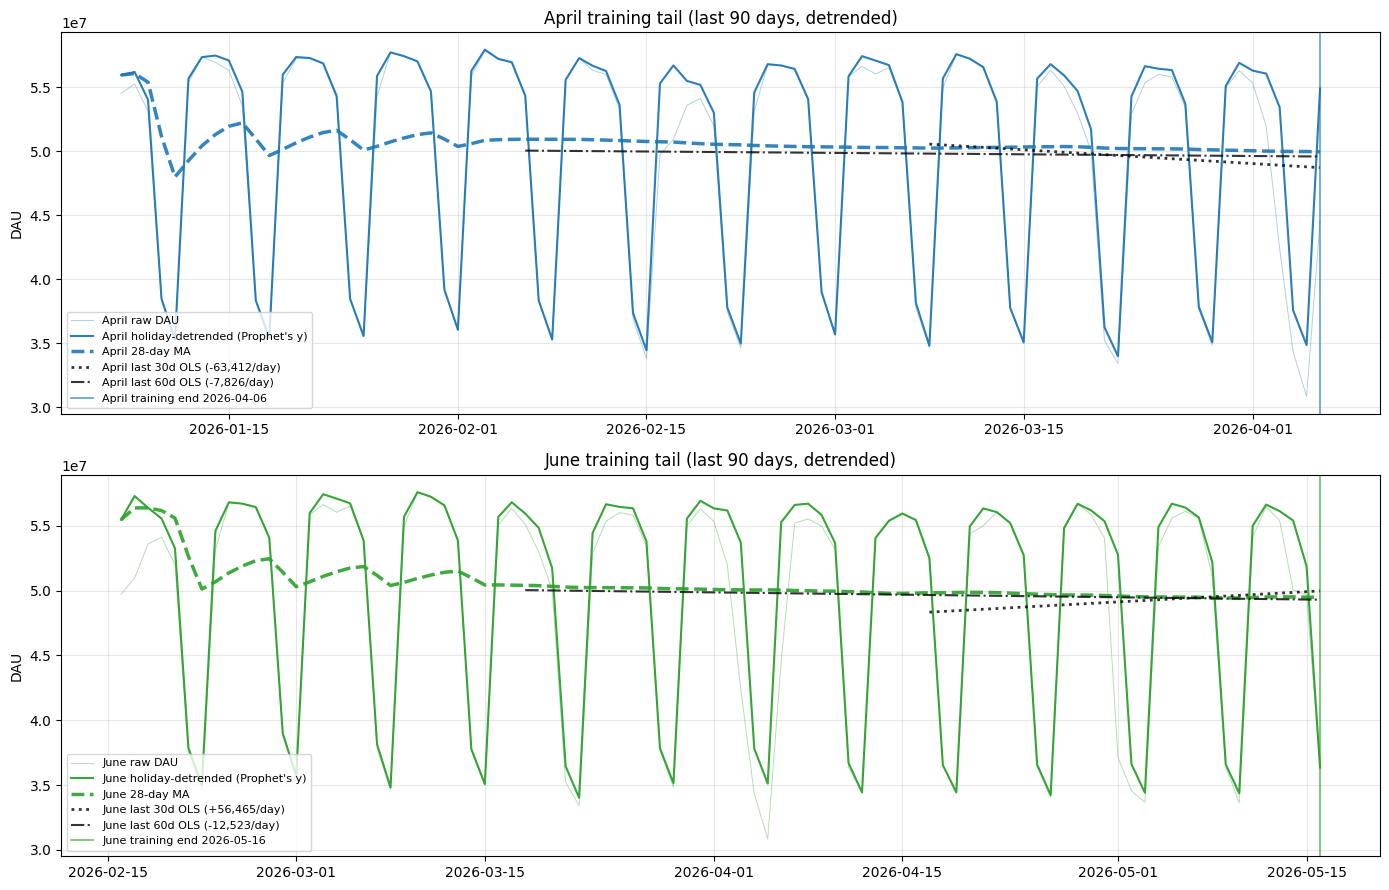

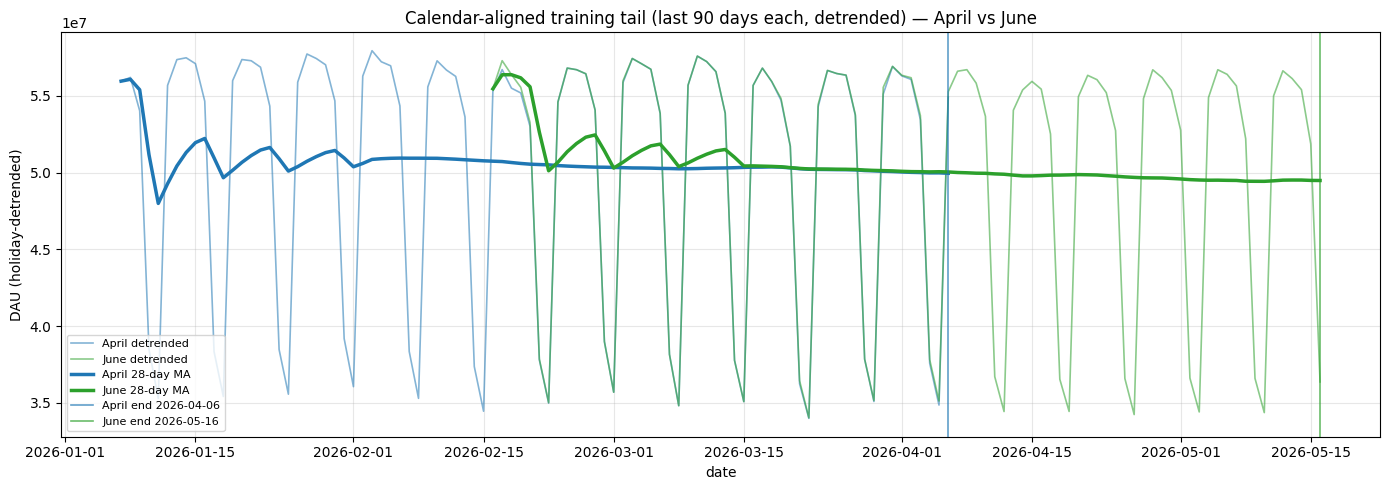

In [17]:
# [plot-training-tail]
# Compare the last 90 days of training data for April vs June (holiday-detrended, since
# that's what Prophet sees as y). Overlay 28-day MA and OLS slopes on last 30 / last 60
# days for each fit. Question: is the recent slope flip a sustained inflection or noise?

TAIL_DAYS = 90

def training_tail_frame(mz, n_days):
    dates = pd.DatetimeIndex(mz.historical_dates)
    raw = np.asarray(mz.raw_historical_data, dtype=float)
    detrended = np.asarray(mz.holiday_detrended_historical_data, dtype=float)
    tail_start = dates[-1] - pd.Timedelta(days=n_days - 1)
    mask = dates >= tail_start
    df = pd.DataFrame(
        {"raw": raw[mask], "detrended": detrended[mask]},
        index=dates[mask],
    )
    df.index.name = "date"
    df["ma28"] = df["detrended"].rolling(28, min_periods=1).mean()
    return df

apr_tail = training_tail_frame(apr_mz, TAIL_DAYS)
jun_tail = training_tail_frame(jun_mz, TAIL_DAYS)

def ols_slope(series, window_days):
    tail = series.iloc[-window_days:]
    t = np.arange(len(tail))
    slope, intercept = np.polyfit(t, tail.values, 1)
    return slope, intercept, tail

def slope_summary(name, df):
    out = {}
    for window in (30, 60, 90):
        slope, intercept, tail = ols_slope(df["detrended"], window)
        out[window] = (slope, intercept, tail)
        print(f"  {name} last {window}d OLS slope: {slope:>+10,.0f} DAU/day  "
              f"(start {tail.index[0].date()} → end {tail.index[-1].date()})")
    return out

print(f"=== OLS slopes on holiday-detrended training tail ===")
apr_slopes = slope_summary("April", apr_tail)
jun_slopes = slope_summary("June ", jun_tail)
print()
print(f"April training end: {apr_mz.historical_dates.iloc[-1].date()}")
print(f"June  training end: {jun_mz.historical_dates.iloc[-1].date()}")
print(f"Days from April end to June end: {(jun_mz.historical_dates.iloc[-1] - apr_mz.historical_dates.iloc[-1]).days}")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

def draw_panel(ax, df, slopes, color, label, training_end):
    ax.plot(df.index, df["raw"],       color=color, lw=0.7, alpha=0.35,
            label=f"{label} raw DAU")
    ax.plot(df.index, df["detrended"], color=color, lw=1.5, alpha=0.95,
            label=f"{label} holiday-detrended (Prophet's y)")
    ax.plot(df.index, df["ma28"],      color=color, lw=2.5, ls="--", alpha=0.9,
            label=f"{label} 28-day MA")
    # Overlay OLS fits for last 30 and last 60 days.
    for window, ls, lw, swatch in ((30, ":", 2.0, "30d"),
                                    (60, "-.", 1.5, "60d")):
        slope, intercept, tail = slopes[window]
        t = np.arange(len(tail))
        ax.plot(tail.index, intercept + slope * t,
                color="black", lw=lw, ls=ls, alpha=0.8,
                label=f"{label} last {swatch} OLS ({slope:+,.0f}/day)")
    ax.axvline(training_end, color=color, ls="-", lw=1.2, alpha=0.7,
               label=f"{label} training end {training_end.date()}")
    ax.set_ylabel("DAU")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(alpha=0.3)

draw_panel(axes[0], apr_tail, apr_slopes, "tab:blue",  "April",
           apr_mz.historical_dates.iloc[-1])
axes[0].set_title(f"April training tail (last {TAIL_DAYS} days, detrended)")

draw_panel(axes[1], jun_tail, jun_slopes, "tab:green", "June",
           jun_mz.historical_dates.iloc[-1])
axes[1].set_title(f"June training tail (last {TAIL_DAYS} days, detrended)")

plt.tight_layout()
plt.show()

# Side-by-side overlay on a single axis, aligned by calendar date — the actual comparison.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(apr_tail.index, apr_tail["detrended"], color="tab:blue",  lw=1.2, alpha=0.55, label="April detrended")
ax.plot(jun_tail.index, jun_tail["detrended"], color="tab:green", lw=1.2, alpha=0.55, label="June detrended")
ax.plot(apr_tail.index, apr_tail["ma28"], color="tab:blue",  lw=2.5, label="April 28-day MA")
ax.plot(jun_tail.index, jun_tail["ma28"], color="tab:green", lw=2.5, label="June 28-day MA")
ax.axvline(apr_mz.historical_dates.iloc[-1], color="tab:blue",  ls="-", lw=1.2, alpha=0.7,
           label=f"April end {apr_mz.historical_dates.iloc[-1].date()}")
ax.axvline(jun_mz.historical_dates.iloc[-1], color="tab:green", ls="-", lw=1.2, alpha=0.7,
           label=f"June end {jun_mz.historical_dates.iloc[-1].date()}")
ax.set_title(f"Calendar-aligned training tail (last {TAIL_DAYS} days each, detrended) — April vs June")
ax.set_ylabel("DAU (holiday-detrended)")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Rolling-truncation counterfactual — when did the slope flip enter the forecast?

Refit June's Prophet model on training data truncated to a series of intermediate cutoffs
between April's training end (2026-03-30) and June's training end (2026-05-16). At each
cutoff, predict over the same horizon and read off the MA28 Dec 15 forecast.

If the Dec 15 forecast drops smoothly as each ~2-week chunk gets added, the slope flip is a
real, sustained shift — no parameter setting can faithfully close the gap. If the forecast
drops sharply at one specific cutoff, that chunk is the culprit and the right investigation
is what happened during those days (data glitch, holiday handling, Iran sub-aggregation,
etc.) rather than Prophet tuning.

4 intermediate cutoffs are refit in parallel via joblib (~30s wallclock).


Refitting June Prophet at 4 cutoffs in parallel (joblib, n_jobs=4)...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    2.7s remaining:    2.7s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    2.7s finished


Done in 2.8s

=== Dec 15 MA28 forecast vs training-end cutoff (June refits + April fit reference) ===
                cutoff  n_train_rows  n_cps  MA28 yhat @ Dec 15  MA28 trend @ Dec 15  MA28 yearly @ Dec 15  raw yhat @ Dec 15
            2026-03-30          2281     25         +48,122,449          +47,051,139            +1,071,310        +52,179,817
            2026-04-13          2295     25         +48,057,284          +46,988,743            +1,068,541        +52,557,631
            2026-04-27          2309     25         +47,935,424          +46,886,619            +1,048,805        +52,645,609
            2026-05-11          2323     25         +47,871,726          +46,843,787            +1,027,939        +52,812,909
            2026-05-16          2328     25         +47,847,964          +46,840,728            +1,007,235        +52,810,559
2026-04-06 (April fit)          2288     25         +48,032,274          +46,986,376            +1,045,899        +53,231,186

=== Per-step MA

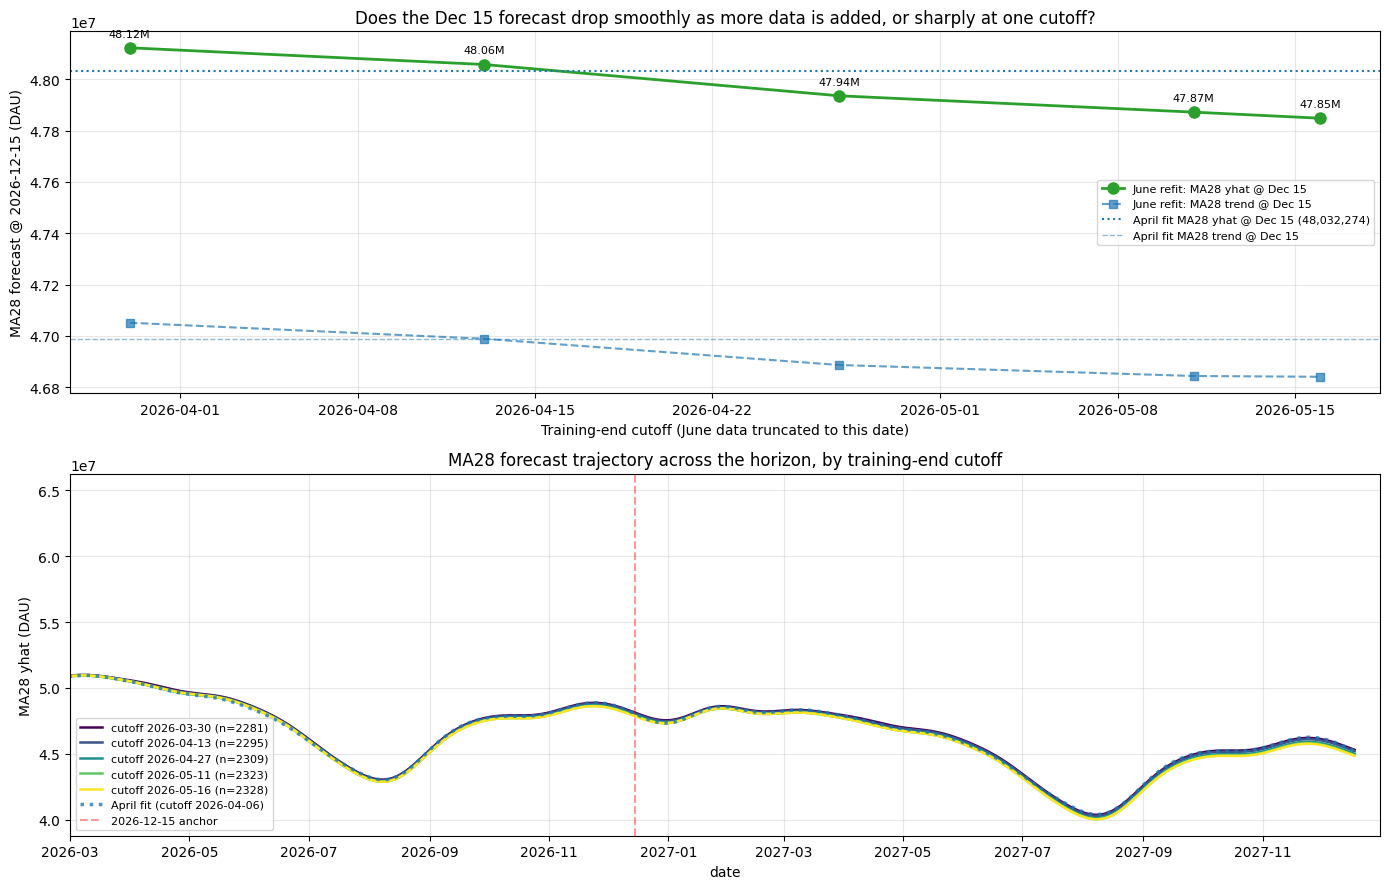

In [18]:
# [rolling-truncation-counterfactual]
# Refit June's Prophet model on training data truncated to a series of cutoffs, then read
# the MA28 Dec 15 forecast at each. Run 4 cutoffs in parallel via joblib.
#
# Each refit replicates the factory exactly (logistic growth, conditional weekly seasonality,
# seed) but the observed DataFrame is truncated to ds <= cutoff. We re-use Prophet's natural
# changepoint placement at each cutoff so that "where Prophet would have put CPs at that
# training end" is part of the counterfactual.

import prophet
from joblib import Parallel, delayed
import time

def refit_with_truncated_training(mz, cutoff, cps_prior_scale, anchor_date):
    """Fit Prophet on June's data truncated to dates <= cutoff. Return cutoff + Dec 15 MA28 yhat
    and a dict of full-frame prediction columns we'll need for plotting."""
    historical_data = np.asarray(mz.holiday_detrended_historical_data, dtype=float)
    historical_dates = pd.DatetimeIndex(mz.historical_dates)
    forecast_dates = pd.DatetimeIndex(mz.forecast_dates)  # keep the same prediction horizon for every fit

    historical_mask = historical_dates < forecast_dates[0]
    observed_full = (
        pd.DataFrame({"ds": historical_dates[historical_mask],
                      "y":  historical_data[historical_mask]})
        .dropna().reset_index(drop=True)
    )
    observed = observed_full[observed_full["ds"] <= cutoff].copy()
    if len(observed) < 365:
        raise ValueError(f"Cutoff {cutoff.date()} leaves only {len(observed)} training rows.")

    params = dict(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        uncertainty_samples=1000,
        seasonality_prior_scale=0.00825,
        changepoint_prior_scale=cps_prior_scale,
        growth="logistic",
        seasonality_mode="additive",
    )

    cap = observed["y"].tail(366).max() * 1.05
    floor = observed["y"].tail(366).min() * (1.0 if cap > 100e6 else 0.92)
    observed["cap"] = cap
    observed["floor"] = floor

    np.random.seed(42)
    m = prophet.Prophet(**params)

    # Conditional weekly seasonalities — matches the factory.
    recent_cutoff = forecast_dates[0] - pd.Timedelta(weeks=13)
    observed["is_historical"] = observed["ds"] < recent_cutoff
    observed["is_recent"] = observed["ds"] >= recent_cutoff
    if observed["is_historical"].any():
        m.add_seasonality(name="weekly_historical", period=7, fourier_order=3, condition_name="is_historical")
    m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")

    m.fit(observed)

    # Predict over the full window (history + forecast) so we can compute MA28 around Dec 15.
    full_ds = pd.date_range(observed["ds"].min(), forecast_dates[-1], freq="D")
    future = pd.DataFrame({"ds": full_ds})
    future["cap"] = cap
    future["floor"] = floor
    future["is_historical"] = future["ds"] < recent_cutoff
    future["is_recent"]     = future["ds"] >= recent_cutoff

    pred = m.predict(future).set_index("ds")

    # MA28 at anchor (centered window, mirrors notebook ma28 definition).
    ma_components = pred[["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]] \
        .rolling(window=28, center=True, min_periods=28).mean()

    return {
        "cutoff": cutoff,
        "n_train_rows": len(observed),
        "ma28_at_anchor": ma_components.loc[anchor_date].to_dict(),
        "raw_at_anchor":  pred.loc[anchor_date, ["trend","yearly","weekly_recent","weekly_historical","yhat"]].to_dict(),
        "ma28_trend_series":  ma_components["trend"],
        "ma28_yhat_series":   ma_components["yhat"],
        "training_end": observed["ds"].max(),
        "n_changepoints_used": len(m.changepoints),
    }

JUNE_CPS_PRIOR = JUNE_PARAMS["changepoint_prior_scale"]
ANCHOR = pd.Timestamp("2026-12-15")

CUTOFFS = [
    pd.Timestamp("2026-03-30"),  # = April training end (sanity check vs April fit)
    pd.Timestamp("2026-04-13"),
    pd.Timestamp("2026-04-27"),
    pd.Timestamp("2026-05-11"),
]
# We don't include 2026-05-16 here because we already have jun_pred_by_date for that.

print(f"Refitting June Prophet at {len(CUTOFFS)} cutoffs in parallel (joblib, n_jobs=4)...")
t0 = time.time()
results = Parallel(n_jobs=4, backend="loky", verbose=5)(
    delayed(refit_with_truncated_training)(jun_mz, c, JUNE_CPS_PRIOR, ANCHOR)
    for c in CUTOFFS
)
print(f"Done in {time.time() - t0:.1f}s")
print()

# Append the existing June fit (full training, 2026-05-16) by computing MA28 from jun_pred_by_date.
jun_full_ma28 = jun_pred_by_date[["trend","yearly","weekly_recent","weekly_historical","yhat"]] \
    .rolling(window=28, center=True, min_periods=28).mean()
results.append({
    "cutoff": pd.Timestamp("2026-05-16"),
    "n_train_rows": int((pd.DatetimeIndex(jun_mz.historical_dates) <= pd.Timestamp("2026-05-16")).sum()),
    "ma28_at_anchor": jun_full_ma28.loc[ANCHOR].to_dict(),
    "raw_at_anchor":  jun_pred_by_date.loc[ANCHOR, ["trend","yearly","weekly_recent","weekly_historical","yhat"]].to_dict(),
    "ma28_trend_series": jun_full_ma28["trend"],
    "ma28_yhat_series":  jun_full_ma28["yhat"],
    "training_end": pd.Timestamp("2026-05-16"),
    "n_changepoints_used": len(jun_m.changepoints),
})

# Build summary table.
rows = []
for r in results:
    rows.append({
        "cutoff":             r["cutoff"].date(),
        "n_train_rows":       r["n_train_rows"],
        "n_cps":              r["n_changepoints_used"],
        "MA28 yhat @ Dec 15": r["ma28_at_anchor"]["yhat"],
        "MA28 trend @ Dec 15":r["ma28_at_anchor"]["trend"],
        "MA28 yearly @ Dec 15": r["ma28_at_anchor"]["yearly"],
        "raw yhat @ Dec 15":  r["raw_at_anchor"]["yhat"],
    })
summary = pd.DataFrame(rows).sort_values("cutoff").reset_index(drop=True)

# Add April baseline for reference.
apr_full_ma28 = apr_pred_by_date[["trend","yearly","weekly_recent","weekly_historical","yhat"]] \
    .rolling(window=28, center=True, min_periods=28).mean()
apr_baseline = pd.DataFrame([{
    "cutoff":             apr_mz.historical_dates.iloc[-1].date(),
    "n_train_rows":       len(apr_mz.historical_dates),
    "n_cps":              len(apr_m.changepoints),
    "MA28 yhat @ Dec 15": apr_full_ma28.loc[ANCHOR, "yhat"],
    "MA28 trend @ Dec 15":apr_full_ma28.loc[ANCHOR, "trend"],
    "MA28 yearly @ Dec 15": apr_full_ma28.loc[ANCHOR, "yearly"],
    "raw yhat @ Dec 15":  apr_pred_by_date.loc[ANCHOR, "yhat"],
}])

print("=== Dec 15 MA28 forecast vs training-end cutoff (June refits + April fit reference) ===")
print(pd.concat([summary, apr_baseline.assign(cutoff=apr_baseline["cutoff"].astype(str) + " (April fit)")], ignore_index=True)
      .to_string(index=False, float_format=lambda x: f"{x:>+,.0f}"))
print()

# Per-step delta — does each ~2-week chunk drag the forecast down smoothly?
print("=== Per-step MA28 yhat Δ as each cutoff adds new training data ===")
yhat_series = summary["MA28 yhat @ Dec 15"].values
cutoffs_str = summary["cutoff"].astype(str).values
for i in range(1, len(yhat_series)):
    delta = yhat_series[i] - yhat_series[i-1]
    print(f"  {cutoffs_str[i-1]} → {cutoffs_str[i]}: MA28 yhat Δ = {delta:>+10,.0f}")
print()
print(f"April fit MA28 yhat @ Dec 15: {apr_baseline['MA28 yhat @ Dec 15'].iloc[0]:>+,.0f}  (reference)")
print(f"June fit  MA28 yhat @ Dec 15: {summary['MA28 yhat @ Dec 15'].iloc[-1]:>+,.0f}  (full data, 2026-05-16)")
total_drop = summary["MA28 yhat @ Dec 15"].iloc[-1] - summary["MA28 yhat @ Dec 15"].iloc[0]
print(f"Total drop from earliest to latest June cutoff: {total_drop:>+,.0f}")
print()

# Plot 1: Dec 15 MA28 forecast vs cutoff date — the main result.
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(summary["cutoff"], summary["MA28 yhat @ Dec 15"], "o-", color="tab:green",
        lw=2.0, markersize=8, label="June refit: MA28 yhat @ Dec 15")
ax.plot(summary["cutoff"], summary["MA28 trend @ Dec 15"], "s--", color="tab:blue",
        lw=1.5, alpha=0.7, label="June refit: MA28 trend @ Dec 15")
ax.axhline(apr_baseline["MA28 yhat @ Dec 15"].iloc[0], color="tab:blue",
           lw=1.5, ls=":", label=f"April fit MA28 yhat @ Dec 15 ({apr_baseline['MA28 yhat @ Dec 15'].iloc[0]:,.0f})")
ax.axhline(apr_baseline["MA28 trend @ Dec 15"].iloc[0], color="tab:blue",
           lw=1.0, ls="--", alpha=0.5, label=f"April fit MA28 trend @ Dec 15")
ax.set_xlabel("Training-end cutoff (June data truncated to this date)")
ax.set_ylabel("MA28 forecast @ 2026-12-15 (DAU)")
ax.set_title("Does the Dec 15 forecast drop smoothly as more data is added, or sharply at one cutoff?")
ax.legend(loc="best", fontsize=8)
ax.grid(alpha=0.3)
for _, row in summary.iterrows():
    ax.annotate(f"{row['MA28 yhat @ Dec 15']/1e6:.2f}M",
                xy=(row["cutoff"], row["MA28 yhat @ Dec 15"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8)

# Plot 2: MA28 trend trajectory across the forecast horizon for each cutoff.
ax = axes[1]
cmap = plt.get_cmap("viridis")
for i, r in enumerate(sorted(results, key=lambda x: x["cutoff"])):
    color = cmap(i / max(1, len(results) - 1))
    label = f"cutoff {r['cutoff'].date()} (n={r['n_train_rows']})"
    ax.plot(r["ma28_yhat_series"].index, r["ma28_yhat_series"].values,
            color=color, lw=1.8, label=label)
ax.plot(apr_full_ma28.index, apr_full_ma28["yhat"], color="tab:blue", lw=2.5, ls=":",
        label=f"April fit (cutoff {apr_mz.historical_dates.iloc[-1].date()})", alpha=0.8)
ax.axvline(ANCHOR, color="r", ls="--", alpha=0.4, label=f"{ANCHOR.date()} anchor")
ax.set_xlim(pd.Timestamp("2026-03-01"), pd.Timestamp("2027-12-31"))
ax.set_xlabel("date")
ax.set_ylabel("MA28 yhat (DAU)")
ax.set_title("MA28 forecast trajectory across the horizon, by training-end cutoff")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cap-override counterfactual — pin June's cap to April's value

The 184k MA28 Dec 15 gap traces to the sliding-window cap rule, not the data. Refit June's
Prophet model with `cap` and `floor` hard-pinned to April's exact values:

- April cap: 63,696,149
- April floor: 29,429,763

Everything else (data, params, changepoints) is left to be computed naturally from June's
training. This is a one-time apples-to-apples adjustment for tomorrow's report — the real fix
belongs in the cap-calculation policy (see options 1-3 in the session discussion).


Pinning June fit to cap=63,696,149, floor=29,429,763 (both from April pkl).


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo


=== MA28 Dec 15 forecast — three fits side by side ===
                   April (gold)  June natural-cap  June + April cap pinned  Δ (capfix − natural)  Δ (capfix − April)
trend               +46,986,376       +46,840,728              +46,888,326               +47,598             -98,050
yearly               +1,045,899        +1,007,235               +1,075,441               +68,205             +29,542
weekly_recent                -0                -0                       -0                    -0                  +0
weekly_historical            +0                +0                       +0                    +0                  +0
yhat                +48,032,274       +47,847,964              +47,963,767              +115,803             -68,508

Original gap (April − June natural): +184,311
Closure from cap fix:                +115,803
Residual gap (April − capfix):       +68,508
% of gap closed by cap fix:          62.8%

=== Raw daily Dec 15 forecast — three fits ===
             

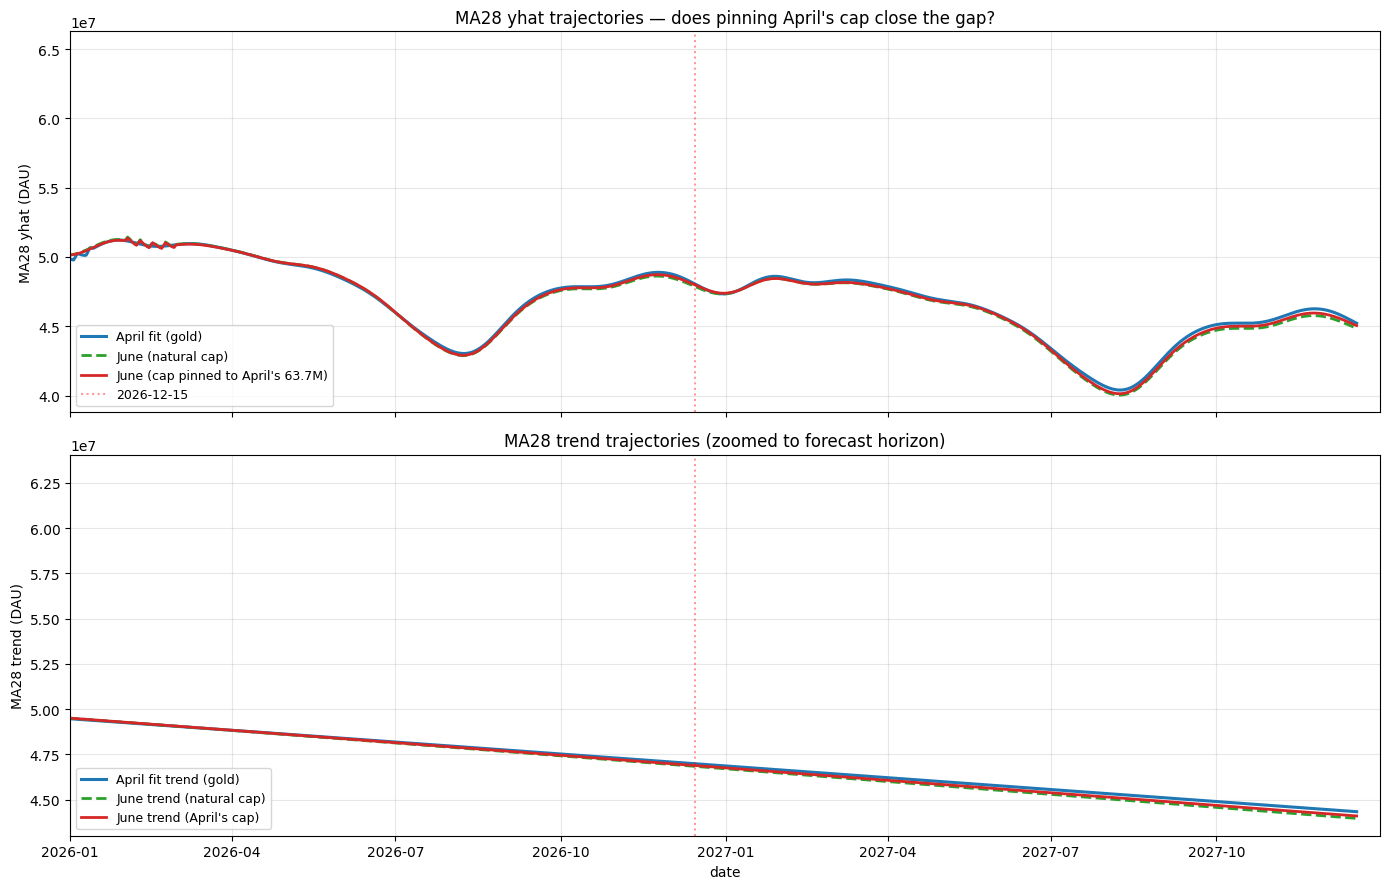

jun_capfix_pred_by_date stashed (shape=(2922, 23)) for downstream use.


In [19]:
# [refit-june-with-april-cap]
# Refit June Prophet with cap/floor pinned to April's exact values. Compare MA28 Dec 15
# yhat to April fit (gold) and June fit (natural cap, baseline).

import prophet

APRIL_CAP   = 63_696_149.0   # from April pkl: max(detrended y, last 366d) * 1.05
APRIL_FLOOR = 29_429_763.0   # from April pkl

def refit_june_with_fixed_cap(mz, cps_prior_scale, cap_val, floor_val):
    """Replicate the factory but override cap/floor instead of computing from observed.y.tail(366)."""
    historical_data = np.asarray(mz.holiday_detrended_historical_data, dtype=float)
    historical_dates = pd.DatetimeIndex(mz.historical_dates)
    forecast_dates = pd.DatetimeIndex(mz.forecast_dates)

    historical_mask = historical_dates < forecast_dates[0]
    observed = (
        pd.DataFrame({"ds": historical_dates[historical_mask],
                      "y":  historical_data[historical_mask]})
        .dropna().reset_index(drop=True)
    )

    params = dict(
        daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True,
        uncertainty_samples=1000, seasonality_prior_scale=0.00825,
        changepoint_prior_scale=cps_prior_scale,
        growth="logistic", seasonality_mode="additive",
    )

    observed["cap"] = cap_val
    observed["floor"] = floor_val

    np.random.seed(42)
    m = prophet.Prophet(**params)

    recent_cutoff = forecast_dates[0] - pd.Timedelta(weeks=13)
    observed["is_historical"] = observed["ds"] < recent_cutoff
    observed["is_recent"] = observed["ds"] >= recent_cutoff
    if observed["is_historical"].any():
        m.add_seasonality(name="weekly_historical", period=7, fourier_order=3, condition_name="is_historical")
    m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")

    m.fit(observed)

    full_ds = pd.date_range(observed["ds"].min(), forecast_dates[-1], freq="D")
    future = pd.DataFrame({"ds": full_ds})
    future["cap"] = cap_val
    future["floor"] = floor_val
    future["is_historical"] = future["ds"] < recent_cutoff
    future["is_recent"] = future["ds"] >= recent_cutoff

    pred = m.predict(future).set_index("ds")
    return m, pred

print(f"Pinning June fit to cap={APRIL_CAP:,.0f}, floor={APRIL_FLOOR:,.0f} (both from April pkl).")
jun_capfix_m, jun_capfix_pred = refit_june_with_fixed_cap(
    jun_mz, JUNE_PARAMS["changepoint_prior_scale"], APRIL_CAP, APRIL_FLOOR
)

components = ["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]
jun_capfix_ma28 = jun_capfix_pred[components].rolling(28, center=True, min_periods=28).mean()
apr_ma28_full = apr_pred_by_date[components].rolling(28, center=True, min_periods=28).mean()
jun_ma28_full = jun_pred_by_date[components].rolling(28, center=True, min_periods=28).mean()

ANCHOR = pd.Timestamp("2026-12-15")

print()
print("=== MA28 Dec 15 forecast — three fits side by side ===")
table = pd.DataFrame({
    "April (gold)":             apr_ma28_full.loc[ANCHOR],
    "June natural-cap":         jun_ma28_full.loc[ANCHOR],
    "June + April cap pinned":  jun_capfix_ma28.loc[ANCHOR],
})
table["Δ (capfix − natural)"] = table["June + April cap pinned"] - table["June natural-cap"]
table["Δ (capfix − April)"]   = table["June + April cap pinned"] - table["April (gold)"]
print(table.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()

apr_yhat = apr_ma28_full.loc[ANCHOR, "yhat"]
jun_yhat = jun_ma28_full.loc[ANCHOR, "yhat"]
fix_yhat = jun_capfix_ma28.loc[ANCHOR, "yhat"]

print(f"Original gap (April − June natural): {apr_yhat - jun_yhat:>+,.0f}")
print(f"Closure from cap fix:                {fix_yhat - jun_yhat:>+,.0f}")
print(f"Residual gap (April − capfix):       {apr_yhat - fix_yhat:>+,.0f}")
pct_closed = (fix_yhat - jun_yhat) / (apr_yhat - jun_yhat) * 100 if (apr_yhat - jun_yhat) else float("nan")
print(f"% of gap closed by cap fix:          {pct_closed:.1f}%")
print()

print("=== Raw daily Dec 15 forecast — three fits ===")
raw_tab = pd.DataFrame({
    "April (gold)":             apr_pred_by_date.loc[ANCHOR, components],
    "June natural-cap":         jun_pred_by_date.loc[ANCHOR, components],
    "June + April cap pinned":  jun_capfix_pred.loc[ANCHOR, components],
})
print(raw_tab.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()

# Sanity: trend gap shrinkage should mirror cap restoration.
trend_gap_orig = apr_ma28_full.loc[ANCHOR, "trend"] - jun_ma28_full.loc[ANCHOR, "trend"]
trend_gap_fix  = apr_ma28_full.loc[ANCHOR, "trend"] - jun_capfix_ma28.loc[ANCHOR, "trend"]
print(f"MA28 trend gap @ Dec 15:")
print(f"  natural cap (June):         April − June trend = {trend_gap_orig:>+,.0f}")
print(f"  pinned to April's cap:      April − fix  trend = {trend_gap_fix:>+,.0f}")
print(f"  closure in trend:           {trend_gap_orig - trend_gap_fix:>+,.0f}")
print()

# Plot the trajectories.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

apr_yhat_series = apr_ma28_full["yhat"]
jun_yhat_series = jun_ma28_full["yhat"]
fix_yhat_series = jun_capfix_ma28["yhat"]

axes[0].plot(apr_yhat_series.index, apr_yhat_series, color="tab:blue",  lw=2.2, label="April fit (gold)")
axes[0].plot(jun_yhat_series.index, jun_yhat_series, color="tab:green", lw=2.0, ls="--", label="June (natural cap)")
axes[0].plot(fix_yhat_series.index, fix_yhat_series, color="tab:red",   lw=2.0, label=f"June (cap pinned to April's {APRIL_CAP/1e6:.1f}M)")
axes[0].axvline(ANCHOR, color="r", ls=":", alpha=0.4, label=f"{ANCHOR.date()}")
axes[0].set_xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2027-12-31"))
axes[0].set_ylabel("MA28 yhat (DAU)")
axes[0].set_title("MA28 yhat trajectories — does pinning April's cap close the gap?")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].grid(alpha=0.3)

apr_trend_series = apr_ma28_full["trend"]
jun_trend_series = jun_ma28_full["trend"]
fix_trend_series = jun_capfix_ma28["trend"]
axes[1].plot(apr_trend_series.index, apr_trend_series, color="tab:blue", lw=2.2, label="April fit trend (gold)")
axes[1].plot(jun_trend_series.index, jun_trend_series, color="tab:green", lw=2.0, ls="--", label="June trend (natural cap)")
axes[1].plot(fix_trend_series.index, fix_trend_series, color="tab:red", lw=2.0, label="June trend (April's cap)")
axes[1].axvline(ANCHOR, color="r", ls=":", alpha=0.4)
axes[1].set_xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2027-12-31"))
axes[1].set_xlabel("date")
axes[1].set_ylabel("MA28 trend (DAU)")
axes[1].set_title("MA28 trend trajectories (zoomed to forecast horizon)")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stash the corrected prediction frame for downstream use / artifact production.
jun_capfix_pred_by_date = jun_capfix_pred
print(f"jun_capfix_pred_by_date stashed (shape={jun_capfix_pred_by_date.shape}) for downstream use.")


## Notes

- Trend is the load-bearing component for the Dec-15 gap (see `june_vs_april_desktop_diagnostic.ipynb`).
- Yearly seasonality is a smooth periodic modifier; differences here would indicate Prophet detected
  a different annual cycle (unlikely on a few weeks of new data).
- Weekly_recent reflects the weekly seasonality during the recent window; differences could matter
  if the recent window slope itself has changed weekly pattern.
- The cross-check cell above proves the re-fit reproduces the saved `.trend` exactly; the same
  underlying Prophet model is responsible for all three plotted components.
